# Introduction: Non-singlet UV PDF Neural Network Training

This notebook constructs a physics-informed neural network (PINN) to model parton distribution functions (PDFs) learned from data and DGLAP residuals. To begin, we focus on modeling the non-singlet valence up-quark (UV) PDF at Q^2 = 1.6129, 10, 100, 500, & 1000 from JAM PDF data, the leading-order non-singlet DGLAP equation, and the valence sum rule.

Updates in this notebook:

* Spikes in the generalization curves have mostly been resolved by switching to CosineAnnealingLR, as a lower LR was needed to avoid jumping out of local minima in the loss landscape. 

* v10 will be used to determine if the SR should be included in the loss function. The percent difference between the SR integral with and without the SR loss function term will be computed. 

* Low-x pred issues have been resolved by fixing the LHS of the DGLAP residual: $\frac{d xq_{NS}(x, Q^2)}{d \ln Q^2}$, rather than $\frac{d q_{NS}(x, Q^2)}{d \ln Q^2}$



# DGLAP Equations Background

The DGLAP (Dokshitzer-Gribov-Lipatov-Altarelli-Parisi) equations handle flavor singlet and non-singlet distributions differently because of gluon coupling.
Here is how the mathematics and physics split between the two categories.
## 1. Non-Singlet Evolution (Decoupled)
Non-singlet distributions describe quantities that carry flavor quantum numbers, such as valence quark distributions ($q_i - \bar{q}_i$) or differences between flavors ($u - d$). [1]

* No Gluon Mixing: Gluons carry no flavor. They cannot directly split into or absorb a specific flavor excess.
* Independent Evolution: Each non-singlet distribution evolves entirely on its own.
* The Equation: It is a single, isolated differential equation:
$$\frac{d q_{NS}(x, Q^2)}{d \ln Q^2} = \frac{\alpha_s(Q^2)}{2\pi} \int_x^1 \frac{dy}{y} P_{qq}\left(\frac{x}{y}\right) q_{NS}(y, Q^2)$$
* Splitting Function: It only requires the quark-to-quark splitting function ($P_{qq}$). [2]

## 2. Singlet Evolution (Coupled Matrix)
The flavor singlet distribution ($\Sigma$) is the sum of all quarks and antiquarks across all active flavors. It represents the total quark density.

* Direct Gluon Mixing: Quarks can radiate gluons, and gluons can split into quark-antiquark pairs. Total quark density and gluon density directly drive each other.
* Matrix Evolution: The equations become a system of two coupled differential equations.
* The Equation: It must be solved simultaneously using a $2 \times 2$ matrix of splitting functions:
$$\frac{d}{d \ln Q^2} \begin{pmatrix} \Sigma(x, Q^2) \\ g(x, Q^2) \end{pmatrix} = \frac{\alpha_s(Q^2)}{2\pi} \int_x^1 \frac{dy}{y} \begin{pmatrix} P_{qq} & 2n_f P_{qg} \\ P_{gq} & P_{gg} \end{pmatrix}\left(\frac{x}{y}\right) \begin{pmatrix} \Sigma(y, Q^2) \\ g(y, Q^2) \end{pmatrix}$$
* Splitting Functions: It requires four functions ($P_{qq}, P_{qg}, P_{gq}, P_{gg}$) and depends on the number of active flavors ($n_f$). [3, 4, 5, 6, 7]

## Key Physical Consequence
As momentum scale ($Q^2$) increases, gluons rapidly split into sea quarks. This causes the singlet distribution to grow explosively at low $x$ values.
In contrast, the non-singlet distribution (like your $u$ valence distribution) does not receive these gluon contributions, causing its total area to remain strictly conserved. [8]





[1] [https://iopscience.iop.org](https://iopscience.iop.org/article/10.1088/1361-6471/ac11c1)
[2] [https://journals.aps.org](https://journals.aps.org/prd/accepted/10.1103/4jvb-24hk)
[3] [https://link.springer.com](https://link.springer.com/article/10.1140/epjc/s10052-026-15417-5)
[4] [https://iopscience.iop.org](https://iopscience.iop.org/article/10.1088/0256-307X/40/9/091201)
[5] [https://link.aps.org](https://link.aps.org/doi/10.1103/2d8y-ljwx)
[6] [https://arxiv.org](https://arxiv.org/html/2604.09534v2)
[7] [https://link.aps.org](https://link.aps.org/doi/10.1103/PhysRevD.110.114011)
[8] [https://www.mdpi.com](https://www.mdpi.com/2571-712X/6/1/15)
[9] [https://ar5iv.labs.arxiv.org](https://ar5iv.labs.arxiv.org/html/1111.5452)



The explicit form of the unpolarized, leading-order (LO) splitting function for flavor non-singlet evolution describes the probability of a quark radiating a gluon and remaining a quark.
## The Explicit Formula
At leading order (one-loop), the non-singlet splitting function $P_{qq}(z)$ is given by:
$$P_{qq}(z) = C_F \left[ \frac{1+z^2}{(1-z)_+} + \frac{3}{2}\delta(1-z) \right]$$
## Key Components Explained

* Color Factor ($C_F$): This represents the color charge of a quark in QCD. Its value is exactly $C_F = \frac{4}{3}$.
* Momentum Fraction ($z$): This is the fraction of the parent quark’s longitudinal momentum retained by the daughter quark after radiating the gluon.
* The Plus-Prescription ($+$): The term $\frac{1}{(1-z)_+}$ is a mathematical distribution used to regularize the infrared divergence that occurs when a gluon is emitted with zero energy ($z \to 1$). It is defined via its integration behavior with a test function $f(z)$:
$$\int_0^1 \frac{f(z)}{(1-z)_+} dz = \int_0^1 \frac{f(z) - f(1)}{1-z} dz$$
* Delta Function ($\delta$): The $\frac{3}{2}\delta(1-z)$ term accounts for virtual gluon corrections (loop diagrams) where no physical gluon is emitted, balancing the real emission divergence.

## The Regularized Alternative Form
You will frequently see this written in an alternative, mathematically equivalent form that avoids the plus-prescription by explicitly grouping the virtual and real emission terms:
$$P_{qq}(z) = C_F \left[ \frac{1+z^2}{1-z} \right]_+ = C_F \left[ \frac{1+z^2}{(1-z)_+} + \frac{3}{2}\delta(1-z) \right]$$
When integrated inside the DGLAP equation, it physically simplifies to:
$$\int_x^1 \frac{dy}{y} P_{qq}\left(\frac{x}{y}\right) q_{NS}(y) = C_F \int_x^1 \frac{dy}{y} \frac{1+\left(\frac{x}{y}\right)^2}{1-\frac{x}{y}} \left[ q_{NS}(y) - \frac{x}{y}q_{NS}(x) \right] + C_F \left( \frac{3}{2} + 2\ln(1-x) \right) q_{NS}(x)$$
## Physical Interpretation

* Soft Gluon Divergence: The denominator $(1-z)$ shows that a quark is highly likely to lose a very small amount of momentum to a “soft” gluon.
* Quark Number Conservation: If you integrate $P_{qq}(z)$ from 0 to 1, the result is exactly zero ($\int_0^1 P_{qq}(z)dz = 0$). This mathematical property guarantees that the total number of valence quarks is strictly conserved during QCD evolution, even as the momentum distribution changes shape.








# PINN Model

## Imports & Auxillary Dictionary

Here we import necessary libraries for neural network construction, data interpolation, and plotting. We also set a seed to ensure network training reproducibility.

The auxillary class is used as a dictionary to store variables used to calculate the alpha_s, the strong coupling factor.

In [1]:

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import zipfile
import copy
import time
import random
import pandas as pd
import matplotlib.pyplot as plt
#from google.colab import drive
from scipy.interpolate import CubicSpline
from mpmath import fp


SEED = 11

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [2]:
class AUX:

    def __init__(self):

        #--set_constants

        self.CA=3.0
        self.CF=4.0/3.0
        self.TR=0.5
        self.TF=0.5
        self.euler=fp.euler

        #--set_masses

        self.me   = 0.000511
        self.mm   = 0.105658
        self.mt   = 1.77684
        self.mu   = 0.055
        self.md   = 0.055
        self.ms   = 0.2
        self.mc   = 1.28
        self.mb   = 4.18

        self.mZ   = 91.1876
        self.mW   = 80.398
        self.M    = 0.93891897
        self.Mpi  = 0.13803
        self.Mk   = 0.493677
        self.Mdelta = 1.232

        self.me2   = self.me**2
        self.mm2   = self.mm**2
        self.mt2   = self.mt**2
        self.mu2   = self.mu**2
        self.md2   = self.md**2
        self.ms2   = self.ms**2
        self.mc2   = self.mc**2
        self.mb2   = self.mb**2
        self.mZ2   = self.mZ**2
        self.mW2   = self.mW**2
        self.M2    = self.M**2
        self.Mpi2  = self.Mpi**2
        self.Mdelta2=self.Mdelta**2

        #--set_couplings

        self.c2w   = self.mW2/self.mZ2
        self.s2w   = 1.0-self.c2w
        self.s2wMZ = 0.23116
        self.c2wMZ = 1.0 - self.s2wMZ
        self.alfa  = 1/137.036
        self.alphaSMZ = 0.118
        self.GF = 1.1663787e-5   # 1/GeV^2

## Load Data

The PDF data set is sourced from trey24_no_sidis_lo.npy, which contains PDFs at Q^2 = 1.6129, 10, 100, 500, and 1000. At each Q^2 value, there are 200 x points, with 1196 replicas each.

Since this data is set on a hybrid log/linear grid, we interpolate the data onto a purely log-spaced grid, using CubicSpline. This allows us to employ Simpson's Rule, which requires equally spaced quadrature points, to numerically approximate the DGLAP convolution.  

We only interpolate the PDF means and bands for +/- one standard deviation from the mean. This will be used in the Chi-Square loss later on in training.


In [4]:

# ── 0. Device ────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ── 1. Load data ──────────────────────────────────────────────────────────────
zip_path = '/work/JAM/rathman/trey24_no_sidis_lo.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open('trey24_no_sidis_lo.npy') as f:
        treypdf = np.load(f, allow_pickle=True).item()

# Original hybrid grid
X_orig = 10**np.linspace(-4, np.log10(0.4), 100)
X_orig = np.append(X_orig, np.linspace(0.4, 1, 101)[1:])

# upper limit tightened from 0.999 to (1 - 1e-6) for consistency
# with the virtual term domain log(1-x). Both now approach x=1 equally.
N_x = 1000
X   = np.logspace(-4, np.log10(1 - 1e-6), N_x)

Q2_vals = [1.6129, 10, 100, 500, 1000]
VAL_Q2  = 500.0
CF = 4.0 / 3.0

#Now interpolate the data for +/- 1 StD. Plot the replica means and StD.

# Interpolate JAM median and +/- 1 Std Dev bands onto the log grid X.
treypdf_log = {}
for q2 in Q2_vals:
    uv_reps        = treypdf[q2]['uv']
    uv_mean_orig   = np.mean(uv_reps, axis=0)
    uv_std_orig    = np.std(uv_reps, axis=0)
    uv_lo_orig     = uv_mean_orig - uv_std_orig     # -1 Std Dev
    uv_hi_orig     = uv_mean_orig + uv_std_orig     # +1 Std Dev

    cs_mean = CubicSpline(X_orig, uv_mean_orig)
    cs_lo  = CubicSpline(X_orig, uv_lo_orig)
    cs_hi  = CubicSpline(X_orig, uv_hi_orig)

    treypdf_log[q2] = {
        'uv'    : cs_mean(X),   # mean on log grid
        'uv_lo' : cs_lo(X),    # -1 Std Dev on log grid
        'uv_hi' : cs_hi(X),    # +1 Std Dev on log grid
    }

print(f'N_x: {N_x} (log-spaced grid: {X.min():.2e} to {X.max():.6f})')

Device: cuda
N_x: 1000 (log-spaced grid: 1.00e-04 to 0.999999)


Let's visualize the PDF data from trey24_no_sidis.npy. We plot the JAM means and +/- one standard deviation on the original hybrid log/linear grid.

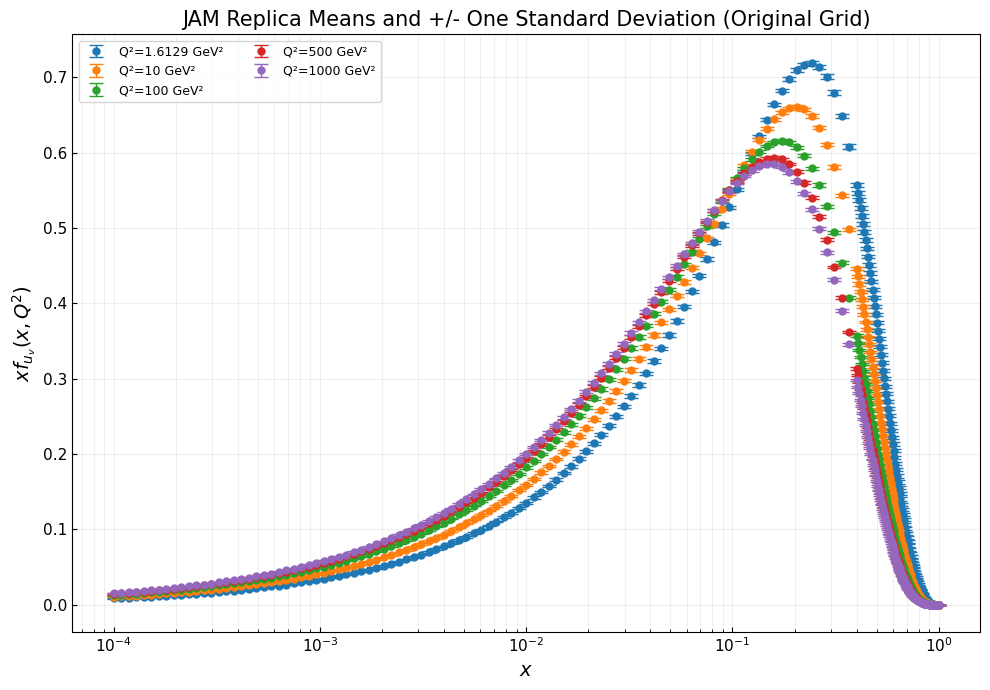

In [4]:
fig, ax = plt.subplots(figsize=(10, 7))

for q2 in Q2_vals:
    uv_reps      = treypdf[q2]['uv']
    uv_mean_orig = np.mean(uv_reps, axis=0)
    uv_std_orig  = np.std(uv_reps, axis=0)

    # Plot mean with error bars representing +/- one standard deviation
    ax.errorbar(X_orig, uv_mean_orig, yerr=uv_std_orig, fmt='o', capsize=5, elinewidth=1.0, markersize = 5, label=f'Q²={q2} GeV²')

ax.set_xscale('log')
ax.set_xlabel(r'$x$', size=14)
ax.set_ylabel(r'$xf_{u_v}(x, Q^2)$', size=14)
ax.set_title('JAM Replica Means and +/- One Standard Deviation (Original Grid)', size=15)
ax.grid(True, which="both", ls="-", alpha=0.2)
ax.tick_params(direction='in', which='both', labelsize=11)
ax.legend(fontsize=9, loc='upper left', ncol=2)

plt.tight_layout()
plt.show()

Interpolated data: Now we have 1000 x points on the purely log-spaced grid.

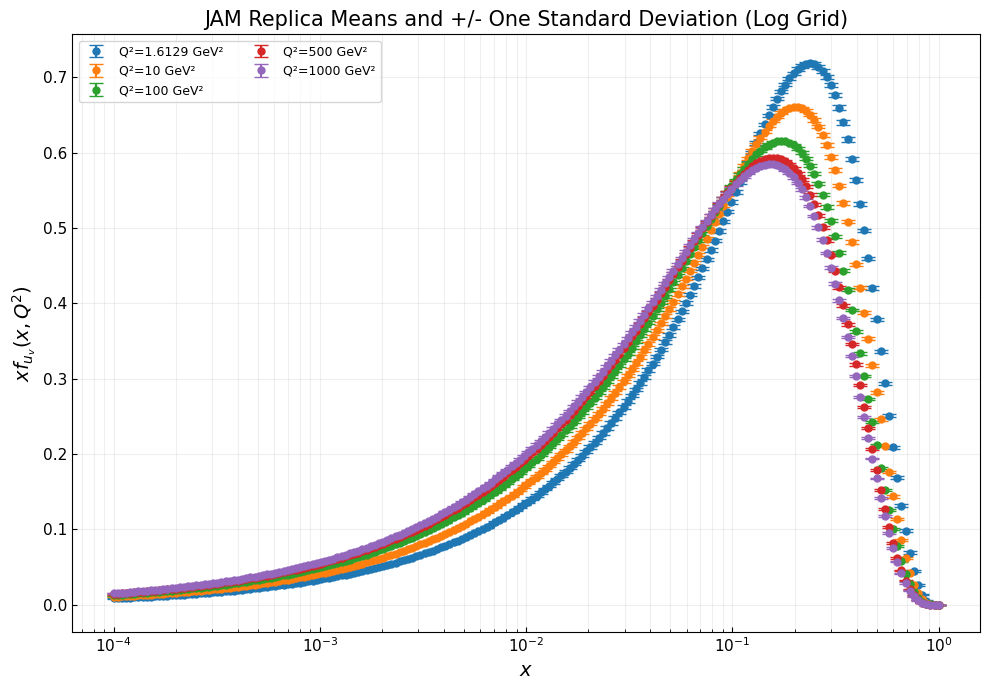

In [8]:
fig, ax = plt.subplots(figsize=(10, 7))

for q2 in Q2_vals:
    # Using the pre-interpolated log-spaced data
    uv_mean_log = treypdf_log[q2]['uv']
    uv_lo_log   = treypdf_log[q2]['uv_lo']
    uv_hi_log   = treypdf_log[q2]['uv_hi']

    # Calculate std dev from the interpolated hi/lo bands
    uv_std_log = (uv_hi_log - uv_lo_log) / 2.0

    # Plot mean with error bars representing +/- one standard deviation
    ax.errorbar(X, uv_mean_log, yerr=uv_std_log, fmt='o', capsize=5, elinewidth=1.5, markersize=5, label=f'Q²={q2} GeV²')

ax.set_xscale('log')
ax.set_xlabel(r'$x$', size=14)
ax.set_ylabel(r'$xf_{u_v}(x, Q^2)$', size=14)
ax.set_title('JAM Replica Means and +/- One Standard Deviation (Log Grid)', size=15)
ax.grid(True, which="both", ls="-", alpha=0.2)
ax.tick_params(direction='in', which='both', labelsize=11)
ax.legend(fontsize=9, loc='upper left', ncol=2)

plt.tight_layout()
plt.show()

## Define Running Coupling

In [5]:
class ALPHAS:

    def __init__(self,order=1):
        """
        order=0: 1-loop
        order=1: 2-loops
        """
        if 'order' in conf: order=conf['order']
        self.order=order
        self.mu20=1
        self.setup()

    def setup(self):
        aux = conf['aux']

        #--setup the beta function
        self.beta=np.zeros((7,3))
        for Nf in range(3,7):
            self.beta[Nf,0]=11.0-2.0/3.0*Nf
            self.beta[Nf,1]=102.-38.0/3.0*Nf
            self.beta[Nf,2]=2857.0/2.0-5033.0/18.0*Nf+325.0/54.0*Nf**2

        # uses alphaS(mZ)--> backwards evolution
        self.aZ  = conf['aux'].alphaSMZ/(4*np.pi)
        self.ab=self.evolve_a(self.aZ,aux.mZ2,aux.mb2,5)
        self.ac=self.evolve_a(self.ab,aux.mb2,aux.mc2,4)
        self.a0=self.evolve_a(self.ac,aux.mc2,self.mu20,3)

        # we will store all Q2 values of alphaS
        self.storage={}


    def get_Nf(self,mu2):
        aux = conf['aux']
        Nf=3
        if mu2>=(aux.mc2): Nf+=1
        if mu2>=(aux.mb2): Nf+=1
        return Nf

    def beta_func(self,a,Nf):
        betaf = -self.beta[Nf,0]
        if self.order>=1: betaf+=-a*self.beta[Nf,1]
        if self.order>=2: betaf+=-a*self.beta[Nf,2]
        return betaf*a**2

    def evolve_a(self,a0,mu20,mu2,Nf):
        # Runge-Kutta implemented in pegasus
        LR = np.log(mu2/mu20)/20.0
        a=a0
        for k in range(20):
            XK0 = LR * self.beta_func(a,Nf)
            XK1 = LR * self.beta_func(a + 0.5 * XK0,Nf)
            XK2 = LR * self.beta_func(a + 0.5 * XK1,Nf)
            XK3 = LR * self.beta_func(a + XK2,Nf)
            a+= (XK0 + 2.* XK1 + 2.* XK2 + XK3) * 0.166666666666666
        return a

    def get_a(self,mu2):
        aux = conf['aux']

        if mu2 not in self.storage:

            if aux.mb2<=mu2:
                mu20,a0,Nf=aux.mb2,self.ab,5
            elif aux.mc2<=mu2 and mu2<aux.mb2:
                mu20,a0,Nf=aux.mc2,self.ac,4
            elif mu2<aux.mc2:
                mu20,a0,Nf=self.mu20,self.a0,3
            self.storage[mu2]=self.evolve_a(a0,mu20,mu2,Nf)

        return self.storage[mu2]

    def get_alphaS(self,mu2):
        return self.get_a(mu2)*4*np.pi

conf = {}
conf['aux']   = AUX()
conf['order'] = 0    # LO running: one-loop beta function, consistent with LO splitting function
mu2=conf['aux'].mZ2

alphas_runner = ALPHAS()


In [6]:
# Precompute running alpha_s for all training Q² values.
# get_alphaS returns a Python float; convert to float32 scalar tensor
# for use inside dglap_convolution which operates in torch.
alphas_Q2 = {
    q2: torch.tensor(alphas_runner.get_alphaS(q2), dtype=torch.float32, device=device)
    for q2 in Q2_vals
}

print('Running alpha_s values:')
for q2, a in alphas_Q2.items():
    print(f'  Q² = {q2:>8.4f} GeV²  →  alpha_s = {a.item():.6f}')

Running alpha_s values:
  Q² =   1.6129 GeV²  →  alpha_s = 0.319246
  Q² =  10.0000 GeV²  →  alpha_s = 0.230247
  Q² = 100.0000 GeV²  →  alpha_s = 0.173084
  Q² = 500.0000 GeV²  →  alpha_s = 0.147941
  Q² = 1000.0000 GeV²  →  alpha_s = 0.139230


## Build Training/Validation Tensors & Define Collocation Points

The training and valiation tensors are then constructed using the interpolated data. The neural network target will be the JAM UV means at Q^2=1.6129, 10, 100, 500, and 1000, which serve as the boundary conditions to guide the network in the PDF's kinematic dependence.

The network input is (x, ln(x), ln(Q^2)), and the output is xf(x, Q^2).

PDF data at Q^2=500 is used to build a validation tensor, which will indicate the network's ability to generalize to unseen data.

The collocation grid includes all x data points. This grid defines (x, Q^2) points where the DGLAP covolution will be evaluated.

In [7]:
# ── 2. Build train / val tensors using interpolated data ───────────────────
log_x = np.log(X)

train_inp, train_tgt, train_std = [], [], []
val_inp,   val_tgt,   val_std   = [], [], []

# Define the Q^2 values to use for data training
DATA_TRAIN_Q2_VALS = [1.6129, 10, 100, 1000]

for q2 in Q2_vals:
    uv_mean = treypdf_log[q2]['uv']
    uv_std  = (treypdf_log[q2]['uv_hi'] - treypdf_log[q2]['uv_lo']) / 2.0 # Standard deviation from +/- 1 Std Dev band
    log_q2    = np.full(N_x, np.log(q2))
    inp       = np.stack([X, log_x, log_q2], axis=1) # Stack X, ln(X), and ln(Q^2) as input features
    tgt       = uv_mean[:, None]
    std       = uv_std[:, None]

    if q2 in DATA_TRAIN_Q2_VALS:
        train_inp.append(inp)
        train_tgt.append(tgt)
        train_std.append(std)
    elif q2 == VAL_Q2:
        val_inp.append(inp)
        val_tgt.append(tgt)
        val_std.append(std)

train_X   = torch.tensor(np.concatenate(train_inp), dtype=torch.float32).to(device)
train_Y   = torch.tensor(np.concatenate(train_tgt), dtype=torch.float32).to(device)
train_STD = torch.tensor(np.concatenate(train_std), dtype=torch.float32).to(device)
val_X     = torch.tensor(np.concatenate(val_inp),   dtype=torch.float32).to(device)
val_Y     = torch.tensor(np.concatenate(val_tgt),   dtype=torch.float32).to(device)
val_STD   = torch.tensor(np.concatenate(val_std),   dtype=torch.float32).to(device)

print(f'train_X: {train_X.shape}  val_X: {val_X.shape}')

train_X: torch.Size([4000, 3])  val_X: torch.Size([1000, 3])


In [8]:
# ── 3. Collocation points ────────────────────────────────────────────────────
#
#  Reuse the training Q² values and the same x grid.
#  VAL_Q2=500 is explicitly excluded so the validation Q² receives
#  no physics-based gradient signal during training.

colloc_inp_list = []

for q2 in Q2_vals:
    if q2 == VAL_Q2:
        continue
    log_q2_col = np.full(N_x, np.log(q2))
    inp        = np.stack([X, log_x, log_q2_col], axis=1)   # (N_x, 3) # Stack X, ln(X), and ln(Q^2) for collocation input
    colloc_inp_list.append(inp)

# Shape: (N_train_Q2 * N_x, 3)  — 4 Q² values × 1000 x points = 4000 rows
# FIX (issue 4): updated from 200 x points / 800 rows; grid is now N_x=1000
colloc_np = np.concatenate(colloc_inp_list)
colloc_X  = torch.tensor(colloc_np, dtype=torch.float32).to(device)

# x_grid as a tensor — needed for Simpson convolution
x_grid_t  = torch.tensor(X, dtype=torch.float32).to(device)

print(f'Collocation grid: {colloc_X.shape}')

Collocation grid: torch.Size([4000, 3])


## Define GL Weights for DGLAP and Sum Rule Integrals

Next, we define quadrature weights to numerically approximate the DGLAP convolution integral with Gauss-Legendre Quadrature. We use the Numpy legendre.leggauss function to generate the nodes and weights for n = 64. (number of nodes chosen with AI to balance the computational cost vs accuracy.



In [9]:
# ── Gauss-Legendre nodes and weights (for DGLAP convolution) ────────────────
from numpy.polynomial.legendre import leggauss

N_GL = 16
gl_nodes_np, gl_weights_np = leggauss(N_GL)
gl_nodes   = torch.tensor(gl_nodes_np,   dtype=torch.float32, device=device)
gl_weights = torch.tensor(gl_weights_np, dtype=torch.float32, device=device)
print(f'GL nodes: {gl_nodes.shape}, GL weights sum={gl_weights.sum().item():.6f} (should = 2.0)')

GL nodes: torch.Size([16]), GL weights sum=2.000000 (should = 2.0)


In [10]:
# ── GL nodes for sum rule in t = -ln(x) space ───────────────────────────────
# Substitution x = e^{-t}  =>  dx = -x dt, so
#     ∫_{x_min}^{x_max} f(x) dx  =  ∫_{T_min}^{T_max} xf(x) dt
# The 1/x in f(x) = xf(x)/x cancels exactly against the Jacobian |dx/dt| = x,
# so the t-space integrand is just xf(x) -- the quantity already stored in
# treypdf -- no division by x anywhere. xf(x) ~ x^0.5 -> 0 smoothly as t -> inf,
# so there's no endpoint singularity and GL recovers its normal exponential
# convergence. This mirrors the DGLAP t=ln(y) convention already used
# elsewhere in the notebook.

from numpy.polynomial.legendre import leggauss

N_GL_SR  = 32
SR_X_MAX = 1.0            # x = 1  -> T_MIN = 0
SR_X_MIN = X_orig.min()   # 1e-4 -- stay within the JAM replica grid's support;
                          # going below this would require extrapolating the
                          # data itself, a separate question from quadrature accuracy

T_MIN = -np.log(SR_X_MAX)   # = 0
T_MAX = -np.log(SR_X_MIN)   # ≈ 9.21

gl_nodes_sr_np, gl_weights_sr_np = leggauss(N_GL_SR)

half_range_sr = (T_MAX - T_MIN) / 2.0
mid_sr        = (T_MAX + T_MIN) / 2.0

t_sr_nodes_np = mid_sr + half_range_sr * gl_nodes_sr_np   # (N_GL_SR,) in t-space
x_sr_nodes_np = np.exp(-t_sr_nodes_np)                     # mapped back to x

x_sr_nodes    = torch.tensor(x_sr_nodes_np,    dtype=torch.float32, device=device)
t_sr_nodes    = torch.tensor(t_sr_nodes_np,    dtype=torch.float32, device=device)
gl_weights_sr = torch.tensor(gl_weights_sr_np, dtype=torch.float32, device=device)
log_x_sr      = -t_sr_nodes   # ln(x) = -t, kept in case a network input needs it

print(f'SR GL nodes: {N_GL_SR}')
print(f'Integration domain (x): [{SR_X_MIN:.1e}, {SR_X_MAX:.6f}]')
print(f'Integration domain (t): [{T_MIN:.4f}, {T_MAX:.4f}]')
print(f'Jacobian (T_MAX-T_MIN)/2: {half_range_sr:.6f}')
print(f'Smallest x node: {x_sr_nodes_np.min():.3e}  (t = {t_sr_nodes_np.max():.4f})')
print(f'Largest  x node: {x_sr_nodes_np.max():.6f}  (t = {t_sr_nodes_np.min():.4f})')

SR GL nodes: 32
Integration domain (x): [1.0e-04, 1.000000]
Integration domain (t): [-0.0000, 9.2103]
Jacobian (T_MAX-T_MIN)/2: 4.605170
Smallest x node: 1.013e-04  (t = 9.1977)
Largest  x node: 0.987479  (t = 0.0126)


## NS Splitting Function and DGLAP Convolution

Previously we defined the LO non-singlet splitting function $P_{qq}(z)$ as:

$$P_{qq}(z) = C_F \left[ \frac{1+z^2}{(1-z)_+} + \frac{3}{2}\delta(1-z) \right]$$


We then examined a regularized alternative form
:
$$P_{qq}(z) = C_F \left[ \frac{1+z^2}{1-z} \right]_+ = C_F \left[ \frac{1+z^2}{(1-z)_+} + \frac{3}{2}\delta(1-z) \right]$$

Which, when integrated inside the DGLAP equation, becomes:

$$\int_x^1 \frac{dy}{y} P_{qq}\left(\frac{x}{y}\right) q_{NS}(y) = C_F \int_x^1 \frac{dy}{y} \frac{1+\left(\frac{x}{y}\right)^2}{1-\frac{x}{y}} \left[ q_{NS}(y) - \frac{x}{y}q_{NS}(x) \right] + C_F \left( \frac{3}{2} + 2\ln(1-x) \right) q_{NS}(x)$$


Now, we define a function to numerically approximate the RHS of the NS DGLAP equation at LO (after taking $ t = ln(y)$ ):

$$\frac{d q_{NS}(x, Q^2)}{d \ln Q^2} = \frac{\alpha_s(Q^2)}{2\pi} C_F
\left[
    \int_{\ln x}^{0}
    \frac{1 + \left(\frac{x}{e^t}\right)^2}{1 - \frac{x}{e^t}}
    \left[ f(e^t) - \frac{x}{e^t}\, f(x) \right] dt
    + \left( \frac{3}{2} + 2\ln(1-x) \right) f(x)
\right]$$

The implemented plus-prescription handles the singularity at $z=1$ by calculating $[f(y) - z \cdot f(x)]$. When $y \to x$ (which means $z \to 1$), the term $(f_y - z f_x)$ goes to zero at the exact same rate as the denominator in the splitting function $(1-z)$. This cancels the infinity, making the result finite and numerically stable.

The kernel, $P_{qq}(z) (f_y- z f_x)$, is then evaluated numerically at Gauss-Legendre nodes, using the previously defined quadrature weights.

The plus-prescription math leaves behind a virtual emission term involving the integral of the splitting function from 0 to 1. This term accounts for the probability that a quark does not radiate. It depends on $\ln(1-x)$ and the constant $3/2$.

In [11]:
def dglap_convolution_gl(xf_fn, x_grid, gl_nodes, gl_weights, alpha_s):
    """
    xf_fn    : callable — takes a tensor of x values, returns xf(x).
                In practice this is a partial application of model(inp)
                for a fixed Q², but the model must be called at the GL nodes.
    x_grid   : (N_x,) query points — the x values we want the RHS at
    gl_nodes : (N_GL,) Gauss-Legendre nodes on [-1, 1]
    gl_weights: (N_GL,) corresponding weights
    alpha_s  : scalar tensor
    """
    N_x  = x_grid.shape[0]
    N_GL = gl_nodes.shape[0]
    ln_xi = torch.log(x_grid)           # (N_x,)   ln(x_i) — negative values

    # ── Map GL nodes to [ln(x_i), 0] for every query point ──────────────────
    # t_nodes[i, j] = GL node j mapped to the integration domain of query i
    # shape: (N_x, N_GL)
    half_range = -ln_xi / 2.0           # (N_x,)   = |ln(x_i)| / 2
    t_mid      = ln_xi / 2.0            # (N_x,)   midpoint of [ln(x_i), 0]

    t_nodes = t_mid.unsqueeze(1) + half_range.unsqueeze(1) * gl_nodes.unsqueeze(0)
    # t_nodes[i, j] = ln(x_i)/2 * (1 - xi_j), shape: (N_x, N_GL)

    y_nodes = torch.exp(t_nodes)        # (N_x, N_GL)  y = e^t for each node

    # ── Evaluate the PDF at the GL nodes ────────────────────────────────────
    # This is the key difference from Simpson: we need f at arbitrary y values,
    # not just the fixed x-grid. xf_fn must accept a flat tensor and return xf.
    y_flat    = y_nodes.reshape(-1)     # (N_x * N_GL,)
    xf_y_flat = xf_fn(y_flat)          # (N_x * N_GL,)
    xf_y      = xf_y_flat.reshape(N_x, N_GL)   # (N_x, N_GL)
    f_y       = xf_y / y_nodes         # f(y) = xf(y)/y

    # ── Plus-prescription subtraction ────────────────────────────────────────
    # FIX (issue 4): cache xf_fn(x_grid) to avoid a second identical
    # forward pass in the virtual term below.
    xf_at_x = xf_fn(x_grid)                              # single cached call
    f_x     = (xf_at_x / x_grid).unsqueeze(1)            # (N_x, 1)
    z   = x_grid.unsqueeze(1) / y_nodes            # (N_x, N_GL)

    kernel    = (1 + z**2) / (1 - z + 1e-12)       # (N_x, N_GL)  P(z)
    integrand = kernel * (f_y - z * f_x)            # (N_x, N_GL)

    # ── Weighted sum with Jacobian ────────────────────────────────────────────
    # Jacobian = half_range = |ln(x_i)| / 2, shape (N_x,)
    jacobian   = half_range.unsqueeze(1)            # (N_x, 1)
    real_term  = (jacobian * (integrand * gl_weights.unsqueeze(0))).sum(dim=1)

    # ── Virtual correction ────────────────────────────────────────────────────
    log_1mx  = torch.log(1.0 - x_grid + 1e-12)
    f_x_diag = xf_at_x / x_grid   # FIX (issue 4): reuse cached result
    virtual  = (1.5 + 2.0 * log_1mx) * f_x_diag

    prefactor = alpha_s / (2 * torch.pi)
    return prefactor * CF * (real_term + virtual)

Now we define the make_xf_fn, which will evaluate the model at the given GL nodes. This is done on a different grid than training since we need to evaluate the PDF at the specific GL nodes.

In [12]:
def make_xf_fn(model, q2, device):
    """Return a callable xf(x) at fixed Q², evaluating the network."""
    log_q2 = np.log(q2)
    def xf_fn(x_vals):
        # x_vals: (N,) tensor of x values (the GL nodes for this query)
        N       = x_vals.shape[0]
        log_x_v = torch.log(x_vals)
        log_q2_v = torch.full((N,), log_q2, device=device, dtype=torch.float32)
        inp      = torch.stack([x_vals, log_x_v, log_q2_v], dim=1)
        return model(inp).squeeze()
    return xf_fn

## Define Neural Network & Hyperparameters

Now we finally define the neural network, which takes $(x, ln(x), ln(Q^2))$  and outputs $x f_{uv}(x, Q^2)$. The positivity of the output PDF prediction (for LO PDFs) is enforced by a final Softplus layer. Currently, hyperbolic tanget activation functions are used.



In [13]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3,  64), nn.Tanh(), # Input layer: 3 features (X, ln(X), ln(Q^2))
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            #nn.Linear(64, 64), nn.Tanh(), #added
            #nn.Linear(64, 64), nn.Tanh(), #added
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64,  1), nn.Softplus()
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

    def chi_square_loss(self, pred, jam_mean, jam_std):
        # Calculate ((NN output - JAM mean) / (one standard deviation))^2
        # Add a small epsilon to jam_std to prevent division by zero
        epsilon = 1e-6
        return torch.mean(((pred - jam_mean) / (jam_std + epsilon))**2)

    def relative_absolute_error(self, pred, jam_mean):
        # Calculate ((NN output - JAM mean) / (JAM mean))
        epsilon = 1e-6
        return torch.mean(torch.abs((pred - jam_mean) / (jam_mean + epsilon)))

model = PINN().to(device)
print(model)
print(f'Parameters: {sum(p.numel() for p in model.parameters())}')

PINN(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=64, bias=True)
    (9): Tanh()
    (10): Linear(in_features=64, out_features=64, bias=True)
    (11): Tanh()
    (12): Linear(in_features=64, out_features=1, bias=True)
    (13): Softplus(beta=1.0, threshold=20.0)
  )
)
Parameters: 21121


We employ data batching to speed up training, with a batch size of 400 and 10 batches/epoch. The Adam optimizer and CosineAnnealing LR learning rate scheduler are used. The early stop patience has been decreased to prevent overfitting. 

In [14]:
# ── 8. Training hyperparameters ───────────────────────────────────────────────

BATCH_SIZE          = 400
N_EPOCHS            = 60000
LOG_EVERY           = 5000
EARLY_STOP_PATIENCE = 1000
LAMBDA_DGLAP        = 10
LAMBDA_DATA         = 1
LAMBDA_SR           = 100

N_TRAIN             = train_X.shape[0]

optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max = N_EPOCHS)


## Training Loop with SR Dict & GL Quad

In [15]:
import torch.nn.functional as F
train_losses, val_losses         = [], []
data_losses_log, phys_losses_log = [], []
sr_losses_log = []
train_rae_log = []
val_rae_log   = []
best_val_loss = float('inf')
best_val_rae  = float('inf')
best_state    = None
no_improve    = 0
# CHANGE: stores {q2: sr_residual_percent} for all Q2 at the best epoch
best_sr_residuals = {}
t0 = time.time()
train_Q2_vals = [q2 for q2 in Q2_vals if q2 != VAL_Q2]
print(f'Training samples    : {N_TRAIN}')
print(f'Batch size          : {BATCH_SIZE}')
print(f'Batches/epoch       : {(N_TRAIN + BATCH_SIZE - 1) // BATCH_SIZE}')
print(f'Early stop patience : {EARLY_STOP_PATIENCE}')
print(f'Lambda Data         : {LAMBDA_DATA}')
print(f'Lambda DGLAP        : {LAMBDA_DGLAP}')
print(f'Lambda Sum Rule     : {LAMBDA_SR}')
print(f'DGLAP Q2 values     : {train_Q2_vals}')
print('Starting...')

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    optimizer.zero_grad()

    # __ (a) Data loss: mini-batch accumulation ____________________________
    perm = torch.randperm(N_TRAIN, device=device)
    batch_chi_sq_losses = []
    for start in range(0, N_TRAIN, BATCH_SIZE):
        idx    = perm[start : start + BATCH_SIZE]
        xb     = train_X[idx]
        yb     = train_Y[idx]
        stdb   = train_STD[idx]
        pred_b = model(xb)
        batch_chi_sq_losses.append(model.chi_square_loss(pred_b, yb, stdb) * len(idx))
    data_loss = torch.sum(torch.stack(batch_chi_sq_losses)) / N_TRAIN

    # __ (b) DGLAP residual: computed once on full collocation grid ________
    x_col      = colloc_X[:, 0:1]
    ln_x_col   = colloc_X[:, 1:2]
    ln_q2_col  = colloc_X[:, 2:3].clone().detach().requires_grad_(True)
    colloc_inp = torch.cat([x_col, ln_x_col, ln_q2_col], dim=1)
    xf_colloc  = model(colloc_inp)
    dxf_dlnq2  = torch.autograd.grad(
        outputs      = xf_colloc,
        inputs       = ln_q2_col,
        grad_outputs = torch.ones_like(xf_colloc),
        create_graph = True,
    )[0]

    dglap_residuals        = []
    sr_integrals_for_logging = {}
    sr_residuals           = []

    for q2 in train_Q2_vals:
        log_q2_val = np.log(q2)
        q2_mask    = (colloc_X[:, 2] - log_q2_val).abs() < 1e-4

        xf_q2  = xf_colloc[q2_mask].squeeze()
        dxf_q2 = dxf_dlnq2[q2_mask].squeeze()
        x_q2   = colloc_X[q2_mask, 0].squeeze()

        df_dlnq2 = dxf_q2 / x_q2

        xf_fn_q2 = make_xf_fn(model, q2, device)
        rhs = dglap_convolution_gl(
            xf_fn_q2, x_grid_t, gl_nodes, gl_weights, alphas_Q2[q2]
        )
        dglap_residuals.append(df_dlnq2 - rhs)

        # ── Sum rule via Gauss–Legendre in t = -ln(x) space ──────────────
        ln_q2_sr = torch.full_like(x_sr_nodes, np.log(q2))
        sr_inp = torch.cat(
            [
                x_sr_nodes.unsqueeze(1),
                log_x_sr.unsqueeze(1),
                ln_q2_sr.unsqueeze(1),
            ],
            dim=1,
        )
        xf_sr        = model(sr_inp).squeeze()
        integral_val = half_range_sr * torch.sum(gl_weights_sr * xf_sr)
        sr_integrals_for_logging[q2] = integral_val.item()
        sr_residuals.append(integral_val - 2.0)

    phys_loss = torch.mean(torch.cat(dglap_residuals)**2)
    sr_loss   = torch.mean(torch.stack(sr_residuals)**2)

    # __ (d) Total loss calculation ________________________________________
    total_loss = LAMBDA_DATA * data_loss + LAMBDA_DGLAP * phys_loss + LAMBDA_SR * sr_loss

    data_grad_norm = 0.0
    phys_grad_norm = 0.0
    sr_grad_norm   = 0.0   # FIX: was never initialised; caused NameError in log print

    if epoch % LOG_EVERY == 0:
        data_grads = torch.autograd.grad(
            LAMBDA_DATA * data_loss, model.parameters(),
            retain_graph=True, allow_unused=True
        )
        data_grad_norm = sum(
            g.norm()**2 for g in data_grads if g is not None
        ).sqrt().item()

        phys_grads = torch.autograd.grad(
            LAMBDA_DGLAP * phys_loss, model.parameters(),
            retain_graph=True, allow_unused=True
        )
        phys_grad_norm = sum(
            g.norm()**2 for g in phys_grads if g is not None
        ).sqrt().item()

        # FIX: sr_grad_norm was referenced in the print but never computed
        sr_grads = torch.autograd.grad(
            LAMBDA_SR * sr_loss, model.parameters(),
            retain_graph=True, allow_unused=True
        )
        sr_grad_norm = sum(
            g.norm()**2 for g in sr_grads if g is not None
        ).sqrt().item()

    # __ (e) Backward pass and optimizer step ______________________________
    total_loss.backward()
    optimizer.step()

    # __ Epoch bookkeeping _________________________________________________
    train_loss    = total_loss.item()
    phys_loss_val = phys_loss.item()
    sr_loss_val   = sr_loss.item()

    model.eval()
    with torch.no_grad():
        val_pred   = model(val_X)
        val_loss   = model.chi_square_loss(val_pred, val_Y, val_STD).item()
        val_rae    = model.relative_absolute_error(val_pred, val_Y).item()
        train_pred = model(train_X)
        train_rae  = model.relative_absolute_error(train_pred, train_Y).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    data_losses_log.append(data_loss.item())
    phys_losses_log.append(phys_loss_val)
    sr_losses_log.append(sr_loss_val)
    train_rae_log.append(train_rae)
    val_rae_log.append(val_rae)

    scheduler.step()

    if val_rae < best_val_rae:
        best_val_rae  = val_rae
        best_val_loss = val_loss
        best_state    = copy.deepcopy(model.state_dict())
        no_improve    = 0

        # CHANGE: evaluate sum rule at ALL Q2 values (train + val) for the
        # best model state so far. VAL_Q2 is included here even though it
        # has no collocation points — we query the model directly at that
        # scale using the same GL-in-t-space integration used during training.
        with torch.no_grad():
            for q2 in Q2_vals:
                ln_q2_sr_best = torch.full_like(x_sr_nodes, np.log(q2))
                sr_inp_best   = torch.cat(
                    [
                        x_sr_nodes.unsqueeze(1),
                        log_x_sr.unsqueeze(1),
                        ln_q2_sr_best.unsqueeze(1),
                    ],
                    dim=1,
                )
                xf_sr_best   = model(sr_inp_best).squeeze()
                integral_best = half_range_sr * torch.sum(
                    gl_weights_sr * xf_sr_best
                ).item()
                best_sr_residuals[q2] = (integral_best - 2.0) / 2.0 * 100  # % error
    else:
        no_improve += 1

    if epoch % LOG_EVERY == 0:
        elapsed          = time.time() - t0
        remaining        = elapsed / epoch * (N_EPOCHS - epoch)
        lr               = optimizer.param_groups[0]['lr']
        ratio_dglap_data = phys_loss_val / (data_loss.item() + 1e-12)
        ratio_sr_data    = sr_loss_val   / (data_loss.item() + 1e-12)

        with torch.no_grad():
            for q2 in train_Q2_vals:
                integral = sr_integrals_for_logging[q2]
                print(f'  Sum rule at Q²={q2:>8.4f}: ∫uv dx = {integral:.4f}  '
                      f'(target 2.0, dev {integral-2.0:+.4f})')

        # FIX: missing newline caused adjacent print statements to be a
        # syntax error; now correctly separated
        print(f'Epoch {epoch:>5}/{N_EPOCHS} | '
              f'Data: {data_loss.item():.2e} | '
              f'DGLAP: {phys_loss_val:.2e} | '
              f'SR: {sr_loss_val:.2e} | '
              f'DGLAP/Data: {ratio_dglap_data:.2e} | '
              f'Val: {val_loss:.2e} | '
              f'Train RAE: {train_rae:.2e} | '
              f'Val RAE: {val_rae:.2e} | '
              f'LR: {lr:.1e} | '
              f'No improve: {no_improve} | '
              f'ETA: {remaining/60:.1f}m')

        # FIX: stray ) closed the f-string early, making the SR grad ratio
        # line an unreachable floating string literal rather than part of the print
        print(f'Epoch {epoch:>5} | '
              f'Data grad norm: {data_grad_norm:.2e} | '
              f'DGLAP grad norm: {phys_grad_norm:.2e} | '
              f'SR grad norm: {sr_grad_norm:.2e} | '
              f'DGLAP grad ratio: {phys_grad_norm/(data_grad_norm+1e-12):.2e} | '
              f'SR grad ratio: {sr_grad_norm/(data_grad_norm+1e-12):.2e}')

    if no_improve >= EARLY_STOP_PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}.')
        break

model.load_state_dict(best_state)
print(f'\nDone. Best val RAE: {best_val_rae*100:.4f}%  |  Best val chi²: {best_val_loss:.4e}')

# CHANGE: print best-state sum rule summary immediately after training
print(f'\nSum rule % error at best epoch (target = 2.0):')
for q2, pct_err in sorted(best_sr_residuals.items()):
    tag = ' (val)' if q2 == VAL_Q2 else '      '
    print(f'  Q²={q2:>8.4f} GeV²{tag}: {pct_err:+.4f}%')

Training samples    : 4000
Batch size          : 400
Batches/epoch       : 10
Early stop patience : 1000
Lambda Data         : 1
Lambda DGLAP        : 10
Lambda Sum Rule     : 100
DGLAP Q2 values     : [1.6129, 10, 100, 1000]
Starting...
  Sum rule at Q²=  1.6129: ∫uv dx = 0.0209  (target 2.0, dev -1.9791)
  Sum rule at Q²= 10.0000: ∫uv dx = 0.0098  (target 2.0, dev -1.9902)
  Sum rule at Q²=100.0000: ∫uv dx = 0.0073  (target 2.0, dev -1.9927)
  Sum rule at Q²=1000.0000: ∫uv dx = 0.0060  (target 2.0, dev -1.9940)
Epoch  5000/60000 | Data: 2.42e+04 | DGLAP: 1.32e+00 | SR: 3.96e+00 | DGLAP/Data: 5.44e-05 | Val: 2.77e+04 | Train RAE: 1.94e+00 | Val RAE: 2.35e+00 | LR: 9.8e-04 | No improve: 0 | ETA: 30.9m
Epoch  5000 | Data grad norm: 7.88e+03 | DGLAP grad norm: 5.53e+02 | SR grad norm: 4.65e+01 | DGLAP grad ratio: 7.02e-02 | SR grad ratio: 5.90e-03
  Sum rule at Q²=  1.6129: ∫uv dx = 1.9624  (target 2.0, dev -0.0376)
  Sum rule at Q²= 10.0000: ∫uv dx = 1.9762  (target 2.0, dev -0.0238)
  

# $X^2$ and RAE vs X

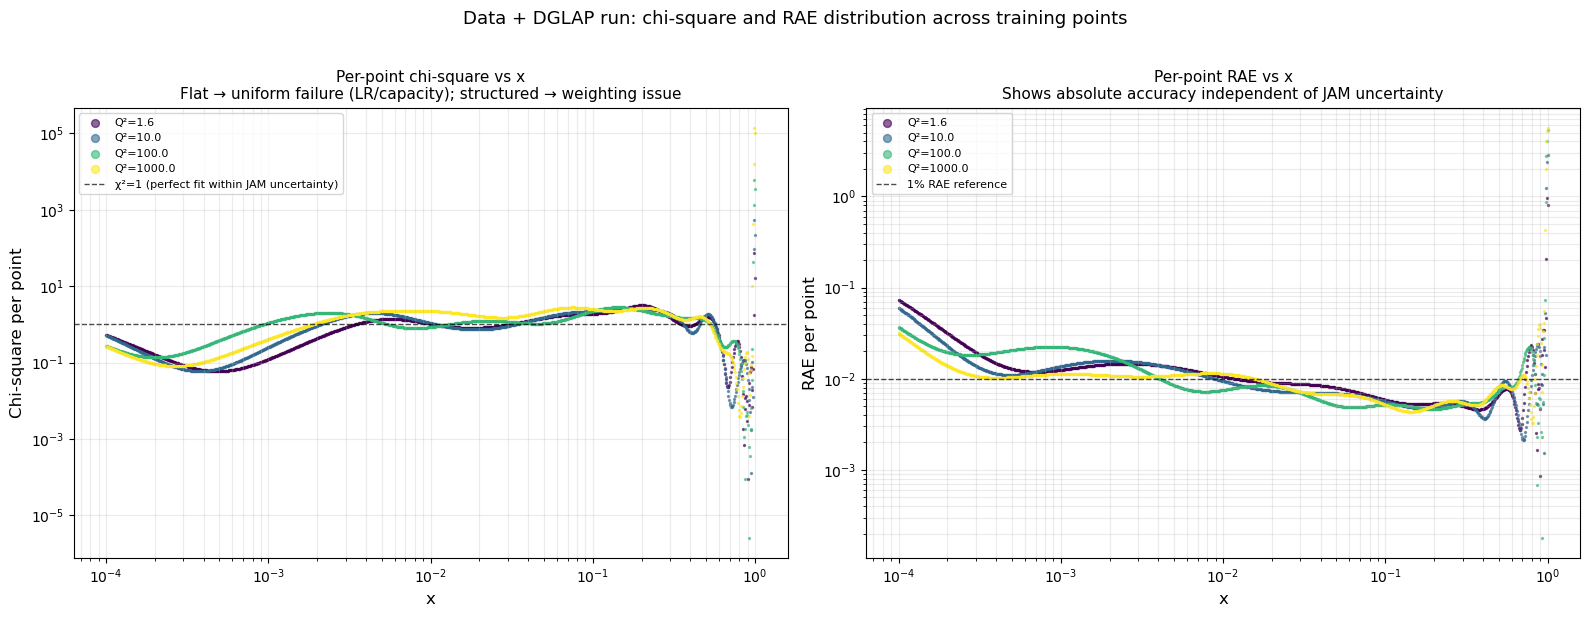

        Q² |    Mean χ² |     Max χ² |  Mean RAE% |   Max RAE%
----------------------------------------------------------
    1.6100 |     1.0191 |    74.1179 |     1.5745 |    96.4950
   10.0000 |     1.8822 |   526.9113 |     1.8596 |   287.4261
  100.0000 |    12.0111 |  6077.5317 |     2.5330 |   536.8054
 1000.0000 |   255.1523 | 137209.7188 |     2.7370 |   559.5654

Overall mean chi-square : 67.5162  (target ~1.0 for perfect fit)
Overall mean RAE        : 2.1760%
Fraction with chi² > 10 : 0.3%  (points more than ~3σ from JAM median)


In [16]:
# ── Diagnostic: per-point chi-square distribution (data-only run) ─────────────
#
# Purpose: determine whether the data loss is failing to improve everywhere
# uniformly (network capacity / LR problem) or only in specific x and Q²
# regions (chi-square + mask weighting problem).
#
# Interpretation:
#   Uniformly large chi-square across all x and Q²
#     → network is not fitting at all → capacity or LR bottleneck 
#   Small chi-square at mid-x, large at small-x / large-x
#     → gradient from difficult regions too weak to drive improvement
#     → chi-square + mask weighting is the bottleneck 
#   Large chi-square concentrated at one Q² slice
#     → that Q² slice is harder to fit, possibly a data or normalisation issue

model.eval()

with torch.no_grad():
    pred_train = model(train_X)

    # Chi-square per point: ((pred - mu) / sigma)^2
    chi2_per_point = ((pred_train - train_Y) / (train_STD + 1e-12))**2  # (N, 1)
    chi2_np        = chi2_per_point.cpu().numpy().flatten()              # (N,)

    # RAE per point: |pred - mu| / (|mu| + eps)
    rae_per_point  = (torch.abs(pred_train - train_Y) /
                      (torch.abs(train_Y) + 1e-6))
    rae_np         = rae_per_point.cpu().numpy().flatten()               # (N,)

# Extract x and Q² values for colouring
x_vals   = train_X[:, 0].cpu().numpy()      # raw x (first input feature)
q2_vals_train = np.exp(train_X[:, 2].cpu().numpy())   # Q² from ln(Q²) column

# ── Plot 1: chi-square per point vs x, coloured by Q² ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
q2_unique = np.unique(np.round(q2_vals_train, 2))
colors_diag = plt.cm.viridis(np.linspace(0, 1, len(q2_unique)))

for q2_val, col in zip(q2_unique, colors_diag):
    mask_q2 = np.abs(q2_vals_train - q2_val) < 1.0
    ax.scatter(x_vals[mask_q2], chi2_np[mask_q2],
               s=2, alpha=0.6, color=col, label=f'Q²={q2_val:.1f}')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('Chi-square per point', fontsize=12)
ax.set_title('Per-point chi-square vs x\n'
             'Flat → uniform failure (LR/capacity); '
             'structured → weighting issue', fontsize=11)
ax.axhline(1.0, color='black', lw=1.0, ls='--', alpha=0.7,
           label='χ²=1 (perfect fit within JAM uncertainty)')
ax.legend(fontsize=8, markerscale=4)
ax.grid(True, which='both', alpha=0.25)

# ── Plot 2: RAE per point vs x, coloured by Q² ───────────────────────────────
ax = axes[1]
for q2_val, col in zip(q2_unique, colors_diag):
    mask_q2 = np.abs(q2_vals_train - q2_val) < 1.0
    ax.scatter(x_vals[mask_q2], rae_np[mask_q2],
               s=2, alpha=0.6, color=col, label=f'Q²={q2_val:.1f}')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('RAE per point', fontsize=12)
ax.set_title('Per-point RAE vs x\n'
             'Shows absolute accuracy independent of JAM uncertainty', fontsize=11)
ax.axhline(0.01, color='black', lw=1.0, ls='--', alpha=0.7,
           label='1% RAE reference')
ax.legend(fontsize=8, markerscale=4)
ax.grid(True, which='both', alpha=0.25)

plt.suptitle('Data + DGLAP run: chi-square and RAE distribution across training points',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Summary statistics per Q² slice ──────────────────────────────────────────
print(f'{"Q²":>10} | {"Mean χ²":>10} | {"Max χ²":>10} | {"Mean RAE%":>10} | {"Max RAE%":>10}')
print('-' * 58)
for q2_val in q2_unique:
    mask_q2  = np.abs(q2_vals_train - q2_val) < 1.0
    print(f'{q2_val:>10.4f} | '
          f'{chi2_np[mask_q2].mean():>10.4f} | '
          f'{chi2_np[mask_q2].max():>10.4f} | '
          f'{rae_np[mask_q2].mean()*100:>10.4f} | '
          f'{rae_np[mask_q2].max()*100:>10.4f}')

print()
print(f'Overall mean chi-square : {chi2_np.mean():.4f}  (target ~1.0 for perfect fit)')
print(f'Overall mean RAE        : {rae_np.mean()*100:.4f}%')
print(f'Fraction with chi² > 10 : {(chi2_np > 10).mean()*100:.1f}%  '
      f'(points more than ~3σ from JAM median)')

Observations:
* The $X^2$ and RAE are both large at ~0.002 and $x>0.6$, indicating the network is not learning those regions properly, 
* However, at low-x, the RAE is large while the $X^2$ is small, indicating that the $X^2$ is too small to guide the network properly in that region

# Plot Training/Validation Loss & Model's PDF Prediction

Let's plot the results of the network training. The training loss represents the total loss:

$\text{total loss} = \lambda_{\text{Data}} \cdot L_{\text{Data}} + \lambda_{\text{DGLAP}} \cdot L_{\text{DGLAP}} + \lambda_{\text{Sum Rule}} \cdot L_{\text{Sum Rule}}$



where $L_{Data}$ is calculated with Chi-Square and $L_{DGLAP}$ & $L_{Sum Rule}$ is calculated with MSE, where Chi-Square is

$$\left(\frac{ \text{ NN Output}\ - f_{uv \text{ JAM mean}}}{\sigma_{uv}}\right)^2$$

The validation loss represents the Chi-Square between the model PDF predictions and the JAM mean PDFs at $Q^2 = 500$.

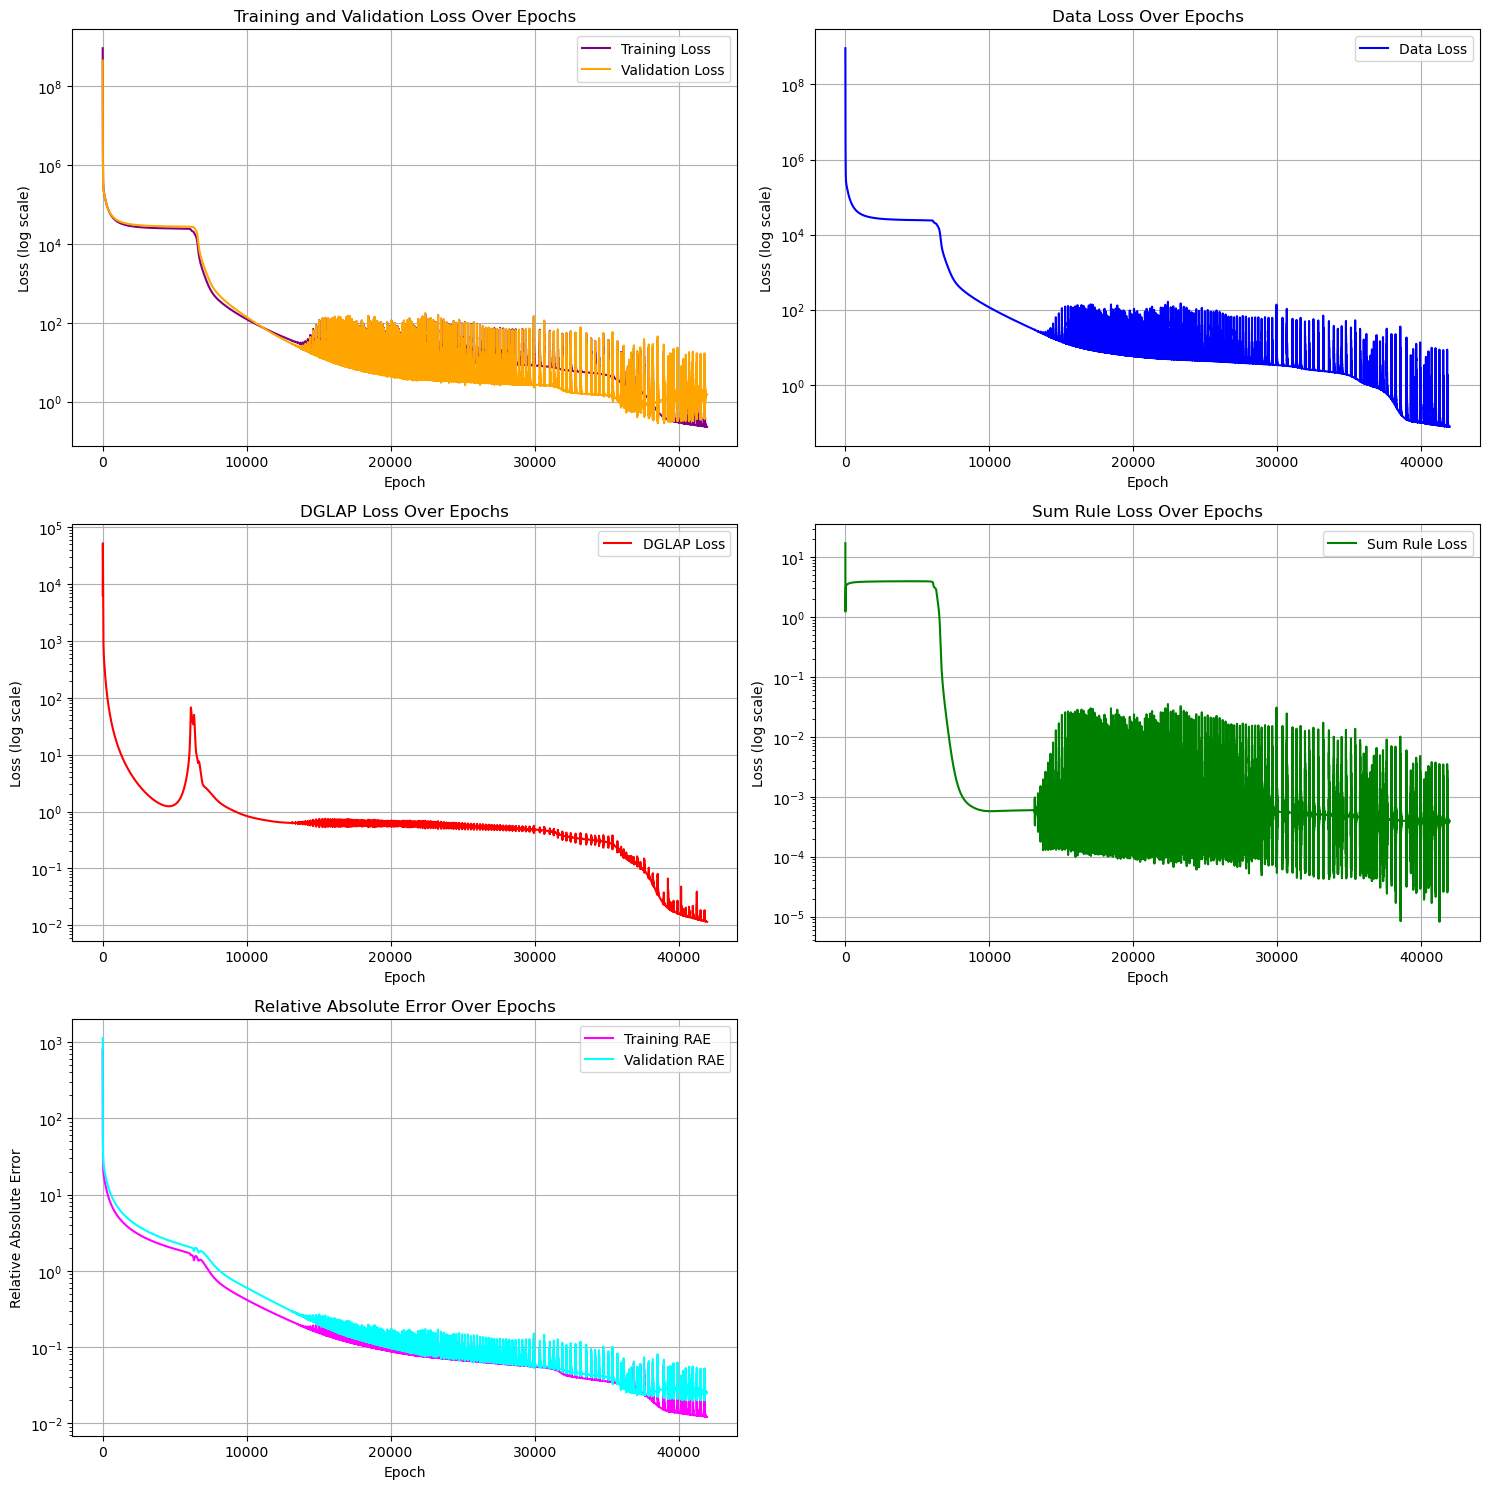

In [17]:
fig, axes_2d = plt.subplots(3, 2, figsize=(15, 15)) # Changed to 3 rows, 2 columns to accommodate new plot
axes = axes_2d.flatten() # Flatten the axes array to ensure 1D access

# Plot Training and Validation Loss
axes[0].plot(train_losses, label='Training Loss', color='purple')
axes[0].plot(val_losses, label='Validation Loss', color='orange')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (log scale)')
axes[0].set_title('Training and Validation Loss Over Epochs')
axes[0].legend()
axes[0].grid(True)
axes[0].set_yscale('log')

# Plot Data Loss (Now at [0, 1])
axes[1].plot(data_losses_log, label='Data Loss', color='blue')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (log scale)')
axes[1].set_title('Data Loss Over Epochs')
axes[1].legend()
axes[1].grid(True)
axes[1].set_yscale('log')

# Plot Physics Loss
axes[2].plot(phys_losses_log, label='DGLAP Loss', color='red') # Changed label for clarity
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss (log scale)')
axes[2].set_title('DGLAP Loss Over Epochs') # Changed title for clarity
axes[2].legend()
axes[2].grid(True)
axes[2].set_yscale('log')

# Plot Sum Rule Loss
axes[3].plot(sr_losses_log, label='Sum Rule Loss', color='green') # New subplot
axes[3].set_xlabel('Epoch')
axes[3].set_ylabel('Loss (log scale)')
axes[3].set_title('Sum Rule Loss Over Epochs')
axes[3].legend()
axes[3].grid(True)
axes[3].set_yscale('log')

# Plot Relative Absolute Error
axes[4].plot(train_rae_log, label='Training RAE', color='magenta')
axes[4].plot(val_rae_log, label='Validation RAE', color='cyan')
axes[4].set_xlabel('Epoch')
axes[4].set_ylabel('Relative Absolute Error')
axes[4].set_title('Relative Absolute Error Over Epochs')
axes[4].legend()
axes[4].grid(True)
axes[4].set_yscale('log')

# Hide the unused 6th subplot if there are only 5 plots
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

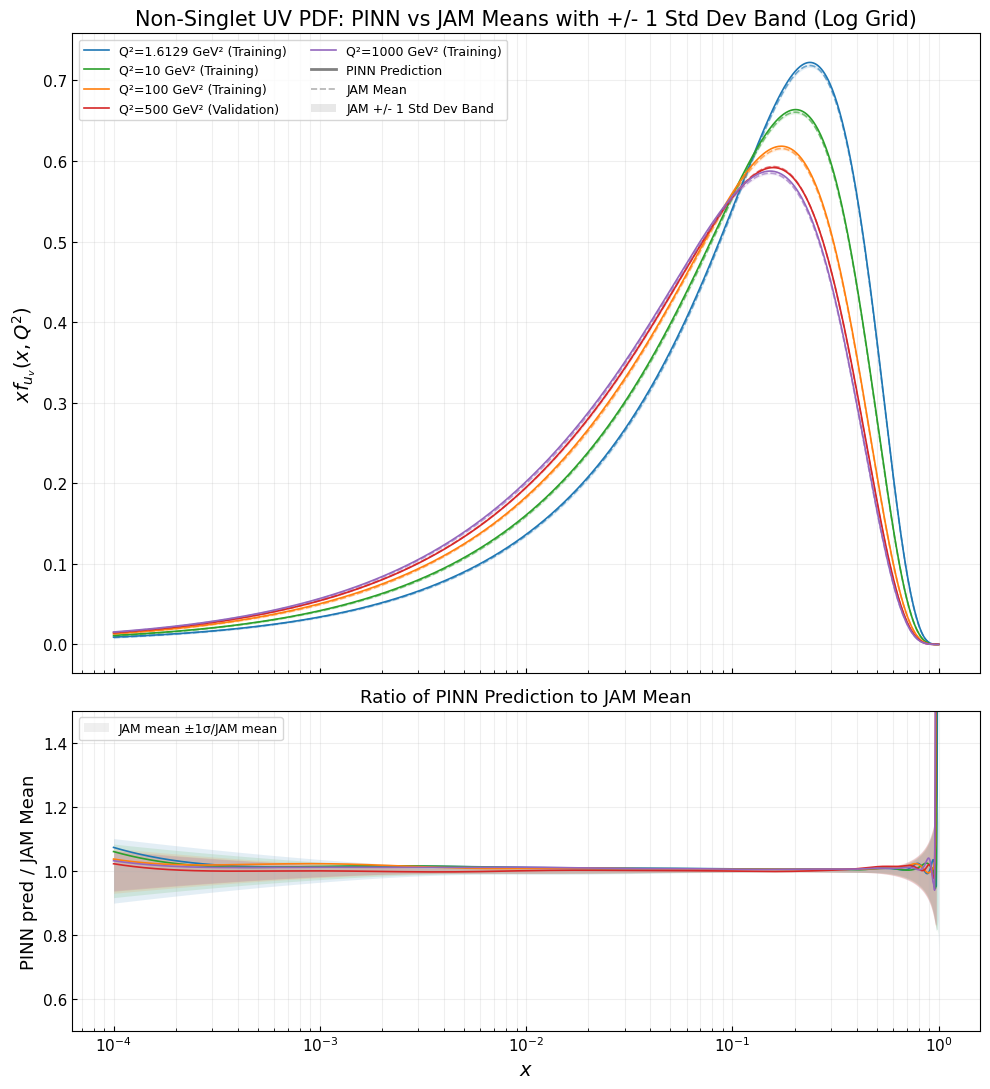

In [18]:
model.eval()
log_x_np = np.log(X)

# Define colors for each Q2 scale
colors = {
    1.6129: '#1f77b4',   # blue
    10:     '#2ca02c',   # green
    100:    '#ff7f0e',   # orange
    500:    '#d62728',   # crimson
    1000:   '#9467bd',   # purple
}

# CHANGE: two-panel figure — top: PDF vs x, bottom: NN/JAM mean ratio
fig, (ax, ax_ratio) = plt.subplots(
    2, 1, figsize=(10, 11),
    gridspec_kw={'height_ratios': [3, 1.5]},
    sharex=True
)

# Store predictions, means, and lo/hi per Q²
preds_by_q2 = {}
means_by_q2 = {}
los_by_q2   = {}
his_by_q2   = {}

for q2 in Q2_vals:
    color = colors.get(q2, 'black')
    label_suffix = ' (Validation)' if q2 == VAL_Q2 else ' (Training)'

    lo   = treypdf_log[q2]['uv_lo']
    hi   = treypdf_log[q2]['uv_hi']
    mean = treypdf_log[q2]['uv']

    ax.fill_between(X, lo, hi, color=color, alpha=0.12, linewidth=0)
    ax.plot(X, mean, color=color, lw=1.2, ls='--', alpha=0.6)

    # NN prediction
    log_q2_np = np.full(N_x, np.log(q2))
    inp_np    = np.stack([X, log_x_np, log_q2_np], axis=1)
    inp_t     = torch.tensor(inp_np, dtype=torch.float32).to(device)
    with torch.no_grad():
        pred = model(inp_t).cpu().numpy().flatten()
    ax.plot(X, pred, color=color, lw=1.2, label=f'Q²={q2} GeV²{label_suffix}')

    preds_by_q2[q2] = pred
    means_by_q2[q2] = mean
    los_by_q2[q2]   = lo
    his_by_q2[q2]   = hi


# ── Top panel formatting ──────────────────────────────────────────────────────
line_nn   = plt.Line2D([0], [0], color='grey', lw=2,        label='PINN Prediction')
line_med  = plt.Line2D([0], [0], color='grey', lw=1.2,
                        ls='--', alpha=0.6,                  label='JAM Mean')
line_band = plt.matplotlib.patches.Patch(facecolor='grey',
                        alpha=0.18,                          label='JAM +/- 1 Std Dev Band')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + [line_nn, line_med, line_band],
          fontsize=9, loc='upper left', ncol=2)
ax.set_ylabel(r'$xf_{u_v}(x, Q^2)$', size=14)
ax.set_title('Non-Singlet UV PDF: PINN vs JAM Means with +/- 1 Std Dev Band (Log Grid)', size=15)
ax.grid(True, which='both', ls='-', alpha=0.2)
ax.tick_params(direction='in', which='both', labelsize=11)

# ── CHANGE: ratio panel — NN prediction / JAM mean ───────────────────────────
# Ratio panel
for q2 in Q2_vals:
    color = colors.get(q2, 'black')
    mean  = means_by_q2[q2]
    pred  = preds_by_q2[q2]
    lo    = los_by_q2[q2]
    hi    = his_by_q2[q2]

    safe  = np.abs(mean) > 1e-6
    ratio = np.where(safe, pred / mean, np.nan)

    upper = np.where(safe, hi / mean, np.nan)
    lower = np.where(safe, lo / mean, np.nan)

    ax_ratio.plot(X, ratio, color=color, lw=1.2)
    ax_ratio.fill_between(X, lower, upper, color=color, alpha=0.12, linewidth=0)


ax_ratio.set_xscale('log')
ax_ratio.set_xlabel(r'$x$', size=14)
ax_ratio.set_ylabel(r'PINN pred / JAM Mean', size=13)
ax_ratio.set_title('Ratio of PINN Prediction to JAM Mean', size=13)
ax_ratio.set_ylim(0.5, 1.5)
ax_ratio.grid(True, which='both', ls='-', alpha=0.2)
ax_ratio.tick_params(direction='in', which='both', labelsize=11)

band_patch = plt.matplotlib.patches.Patch(
    facecolor='grey',
    alpha=0.12,
    label='JAM mean ±1σ/JAM mean'
)
ax_ratio.legend(handles=[band_patch],
                fontsize=9,
                loc='upper left')

plt.tight_layout()
plt.show()

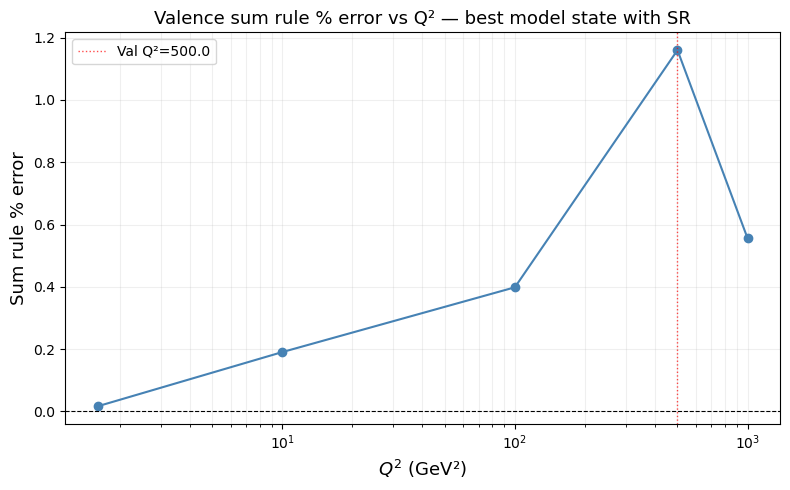

In [19]:
q2_plot  = sorted(best_sr_residuals.keys())
err_plot = [best_sr_residuals[q2] for q2 in q2_plot]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(q2_plot, np.abs(err_plot), 'o-', color='steelblue', lw=1.5, ms=6)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.axvline(VAL_Q2, color='red', lw=1.0, ls=':', alpha=0.7, label=f'Val Q²={VAL_Q2}')
ax.set_xscale('log')
ax.set_xlabel(r'$Q^2$ (GeV²)', fontsize=13)
ax.set_ylabel('Sum rule % error', fontsize=13)
ax.set_title('Valence sum rule % error vs Q² — best model state with SR', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.2)
plt.tight_layout()
plt.show()

# Save Model

In [20]:
save_path = '/work/JAM/rathman/v10_pinn_uv_model_with_GLSR.pt'
torch.save({
    'model_state_dict' : model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'best_val_loss'    : best_val_loss,
    'Q2_vals'          : Q2_vals,
    'val_Q2'           : VAL_Q2,
    'lambda_dglap'     : LAMBDA_DGLAP,
    'alpha_s'          : 'running LO',
    'train_losses'     : train_losses,
    'val_losses'       : val_losses,
    'phys_losses'      : phys_losses_log,
    'sr_losses'        : sr_losses_log,
    'best_sr_residuals' : best_sr_residuals,
    'train_rae_log'    : train_rae_log,
    'val_rae_log'      : val_rae_log,
    'best_val_rae'     : best_val_rae,
'notes'            : 'PINN v10 - No SR loss term, CosineAnnealingLR, stopped at 20,000 epochs'
}, save_path)
print(f'Saved to {save_path}')

Saved to /work/JAM/rathman/v10_pinn_uv_model_with_GLSR.pt


# Continue Training, re-eval $X^2$ per point

In [22]:
import torch.nn.functional as F

# ── RESUME TRAINING FROM CHECKPOINT ───────────────────────────────────────────

# FIX (Bug 4): path now matches what Cell 50 saves.
CHECKPOINT_PATH = '/work/JAM/rathman/v10_pinn_uv_model_with_GLSR.pt'

# ── 1. Load checkpoint ────────────────────────────────────────────────────────
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
print(f'Checkpoint loaded from: {CHECKPOINT_PATH}')

prior_best_val_rae = checkpoint.get('best_val_rae', None)
if prior_best_val_rae is not None:
    print(f'Prior best val RAE: {prior_best_val_rae*100:.4f}%')
else:
    print('Prior best val RAE: not available in checkpoint')

# ── 2. Recover loss history for continuous plotting ───────────────────────────
train_losses  = checkpoint.get('train_losses',  [])
val_losses    = checkpoint.get('val_losses',    [])
phys_losses   = checkpoint.get('phys_losses',   [])
sr_losses     = checkpoint.get('sr_losses',     [])
train_rae_log = checkpoint.get('train_rae_log', [])
val_rae_log   = checkpoint.get('val_rae_log',   [])
epoch_offset  = len(train_losses)
print(f'Resuming from epoch {epoch_offset + 1}')

# ── 3. Hyperparameters for resumed run ────────────────────────────────────────
N_EPOCHS_RESUME     = 30000
EARLY_STOP_PATIENCE = 1000
BATCH_SIZE          = 400
LOG_EVERY           = 2000
LAMBDA_DATA         = 1
LAMBDA_DGLAP        = 10
LAMBDA_SR           = 100

# ── 4. Rebuild optimizer and scheduler — fresh, in the correct order ──────────
#
# FIX (Bug 1): optimizer must be created BEFORE the scheduler, because
# CosineAnnealingLR stores an internal reference to the optimizer object
# at construction time. Constructing the scheduler first and then rebuilding
# the optimizer disconnects them — scheduler.step() would update the old
# orphaned optimizer, and the new one would run at a fixed LR forever.
#
# FIX (Bug 2 + 3): we do NOT load the saved optimizer or scheduler state.
# The original run's Adam moments were accumulated at near-zero LR (cosine
# completed its full cycle at epoch 20000). Loading those stale moments into
# a fresh run at lr=RESUME_LR causes badly miscalibrated first steps, which
# immediately worsens val_rae and burns through the early-stopping patience.
# Starting with fresh moments at a sensible LR gives clean gradient steps
# from epoch 1.  The scheduler starts a new cosine cycle over N_EPOCHS_RESUME.
RESUME_LR = 3e-4   # lower than initial lr=1e-3 — model is near convergence

optimizer = optim.Adam(model.parameters(), lr=RESUME_LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=N_EPOCHS_RESUME, eta_min=1e-6
)

# ── 5. Stabilize early-stopping baseline ─────────────────────────────────────
# Evaluate the loaded model immediately so best_val_rae reflects its actual
# current performance, not float('inf'). Without this the first epoch always
# registers as an improvement and resets no_improve, masking any real plateau.
model.eval()
with torch.no_grad():
    pred_resume = model(val_X)
    rae_resume  = model.relative_absolute_error(pred_resume, val_Y).item()

best_val_rae = rae_resume
best_state   = copy.deepcopy(model.state_dict())
no_improve   = 0

print(f'Stabilized RAE at resume : {best_val_rae*100:.4f}%')
print(f'Resume LR                : {RESUME_LR:.1e}')
print(f'Starting {N_EPOCHS_RESUME} additional epochs...\n')

# ── 6. Training loop ──────────────────────────────────────────────────────────
t0 = time.time()
train_Q2_vals = [q2 for q2 in Q2_vals if q2 != VAL_Q2]

for epoch in range(1, N_EPOCHS_RESUME + 1):

    model.train()
    optimizer.zero_grad()

    # (a) Data loss
    N_TRAIN = train_X.shape[0]
    perm    = torch.randperm(N_TRAIN, device=device)
    batch_chi_sq_losses = []
    for start in range(0, N_TRAIN, BATCH_SIZE):
        idx              = perm[start : start + BATCH_SIZE]
        xb, yb, stdb    = train_X[idx], train_Y[idx], train_STD[idx]
        pred_b           = model(xb)
        batch_chi_sq_losses.append(model.chi_square_loss(pred_b, yb, stdb) * len(idx))
    data_loss = torch.sum(torch.stack(batch_chi_sq_losses)) / N_TRAIN

    # (b) DGLAP residual
    x_col     = colloc_X[:, 0:1]
    ln_x_col  = colloc_X[:, 1:2]
    ln_q2_col = colloc_X[:, 2:3].clone().detach().requires_grad_(True)
    colloc_inp = torch.cat([x_col, ln_x_col, ln_q2_col], dim=1)
    xf_colloc  = model(colloc_inp)

    dxf_dlnq2 = torch.autograd.grad(
        outputs=xf_colloc, inputs=ln_q2_col,
        grad_outputs=torch.ones_like(xf_colloc),
        create_graph=True
    )[0]

    dglap_residuals, sr_residuals = [], []
    sr_integrals_for_logging = {}

    for q2 in train_Q2_vals:
        log_q2_val = np.log(q2)
        q2_mask    = (colloc_X[:, 2] - log_q2_val).abs() < 1e-4

        xf_q2  = xf_colloc[q2_mask].squeeze()
        dxf_q2 = dxf_dlnq2[q2_mask].squeeze()

        # Recover x from ln(x) column 
        x_q2 = colloc_X[q2_mask, 0].squeeze()

        df_dlnq2 = dxf_q2 / x_q2

        xf_fn_q2 = make_xf_fn(model, q2, device)
        rhs = dglap_convolution_gl(
            xf_fn_q2, x_grid_t, gl_nodes, gl_weights, alphas_Q2[q2]
        )

        dglap_residuals.append(df_dlnq2 - rhs)

        integral_val = (xf_q2 * simp_weights).sum()
        sr_integrals_for_logging[q2] = integral_val.item()
        sr_residuals.append(integral_val - 2.0)

    phys_loss = torch.mean(torch.cat(dglap_residuals)**2)
    sr_loss   = torch.mean(torch.stack(sr_residuals)**2)

    # (c) Total loss
    total_loss = LAMBDA_DATA * data_loss + LAMBDA_DGLAP * phys_loss + LAMBDA_SR * sr_loss
    total_loss.backward()
    optimizer.step()
    scheduler.step()

    # (d) Bookkeeping
    model.eval()
    with torch.no_grad():
        val_pred  = model(val_X)
        val_loss  = model.chi_square_loss(val_pred, val_Y, val_STD).item()
        val_rae   = model.relative_absolute_error(val_pred, val_Y).item()
        train_pred = model(train_X)
        train_rae  = model.relative_absolute_error(train_pred, train_Y).item()

    train_losses.append(total_loss.item())
    val_losses.append(val_loss)
    phys_losses.append(phys_loss.item())
    sr_losses.append(sr_loss.item())
    train_rae_log.append(train_rae)
    val_rae_log.append(val_rae)

    if val_rae < best_val_rae:
        best_val_rae = val_rae
        best_state   = copy.deepcopy(model.state_dict())
        no_improve   = 0
    else:
        no_improve  += 1

    if epoch % LOG_EVERY == 0:
        elapsed   = time.time() - t0
        remaining = elapsed / epoch * (N_EPOCHS_RESUME - epoch)
        lr        = optimizer.param_groups[0]['lr']
        with torch.no_grad():
            rae_pp    = torch.abs(model(val_X) - val_Y) / (torch.abs(val_Y) + 1e-6)
            max_rae   = rae_pp.max().item()
        with torch.no_grad():
            for q2 in train_Q2_vals:
                integral = sr_integrals_for_logging[q2]
                print(f'  Sum rule Q²={q2:>8.4f}: ∫uv dx = {integral:.4f} '
                      f'(dev {integral-2.0:+.4f})')
        print(f'Epoch {epoch_offset + epoch:>6} | '
              f'Data: {data_loss.item():.2e} | '
              f'DGLAP: {phys_loss.item():.2e} | '
              f'Mean RAE: {val_rae*100:.3f}% | '
              f'Max RAE: {max_rae*100:.3f}% | '
              f'LR: {lr:.1e} | '
              f'No improve: {no_improve} | '
              f'ETA: {remaining/60:.1f}m')

    if no_improve >= EARLY_STOP_PATIENCE:
        print(f'\nEarly stopping at epoch {epoch_offset + epoch}.')
        break

# ── 7. Restore best weights and save ─────────────────────────────────────────
model.load_state_dict(best_state)
print(f'\nDone. Best mean RAE: {best_val_rae*100:.4f}%')

torch.save({
    'model_state_dict' : best_state,
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'best_val_rae'     : best_val_rae,
    'train_losses'     : train_losses,
    'val_losses'       : val_losses,
    'phys_losses'      : phys_losses,
    'sr_losses'        : sr_losses,
    'train_rae_log'    : train_rae_log,
    'val_rae_log'      : val_rae_log,
    'Q2_vals'          : Q2_vals,
    'val_Q2'           : VAL_Q2,
    'lambda_dglap'     : LAMBDA_DGLAP,
    'lambda_data'      : LAMBDA_DATA,
    'lambda_sr'        : LAMBDA_SR,
    'alpha_s'          : 'running_LO',
    'notes'            : f'Resumed from epoch {epoch_offset}; fresh optimizer at lr={RESUME_LR}'
}, CHECKPOINT_PATH.replace('.pt', '_resumed.pt'))

print('Saved resumed checkpoint.')

Checkpoint loaded from: /work/JAM/rathman/v10_pinn_uv_model_with_SR_resumed.pt
Prior best val RAE: 3.6422%
Resuming from epoch 50001
Stabilized RAE at resume : 3.6422%
Resume LR                : 3.0e-04
Starting 30000 additional epochs...

  Sum rule Q²=  1.6129: ∫uv dx = 1.9855 (dev -0.0145)
  Sum rule Q²= 10.0000: ∫uv dx = 1.9723 (dev -0.0277)
  Sum rule Q²=100.0000: ∫uv dx = 1.9726 (dev -0.0274)
  Sum rule Q²=1000.0000: ∫uv dx = 1.9857 (dev -0.0143)
Epoch  52000 | Data: 1.53e+00 | DGLAP: 2.29e-01 | Mean RAE: 3.610% | Max RAE: 562.875% | LR: 3.0e-04 | No improve: 805 | ETA: 13.2m

Early stopping at epoch 52195.

Done. Best mean RAE: 3.5022%
Saved resumed checkpoint.


Model loaded from: /work/JAM/rathman/v10_pinn_uv_model_with_SR_resumed_resumed.pt


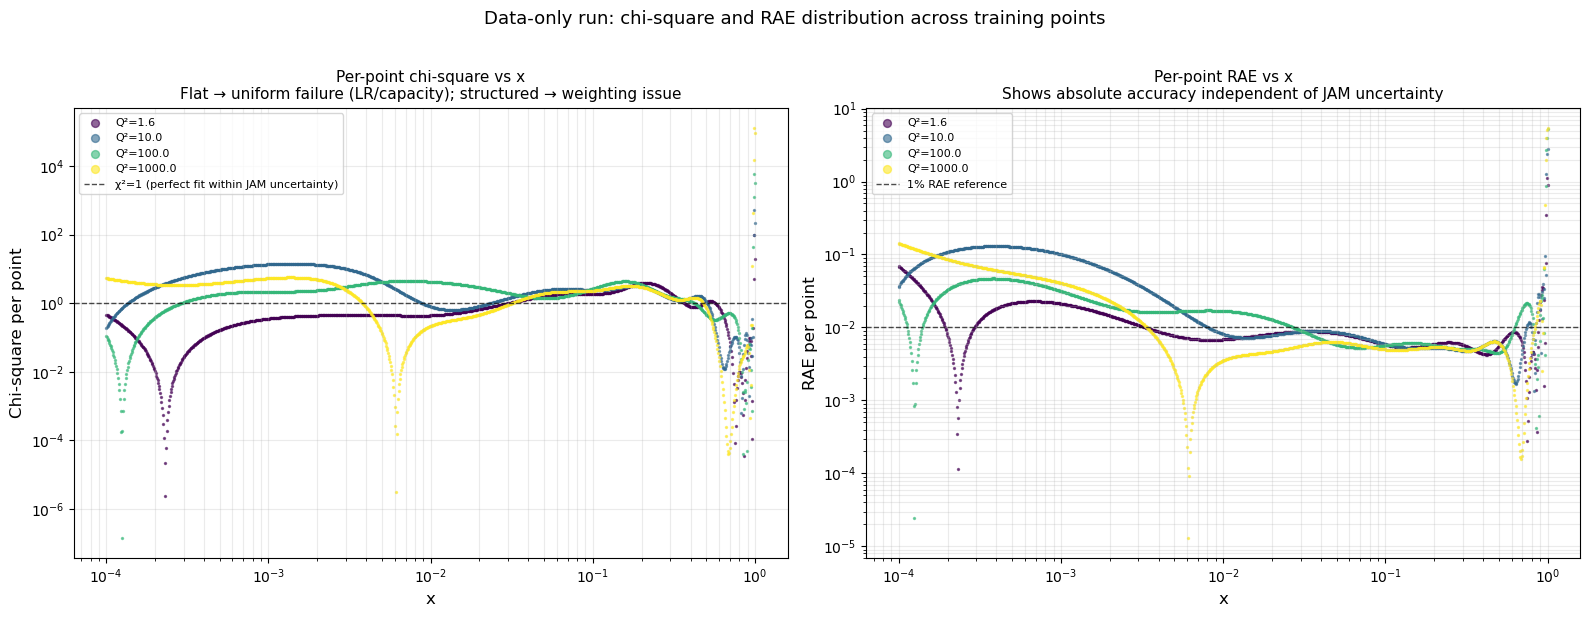

        Q² |    Mean χ² |     Max χ² |  Mean RAE% |   Max RAE%
----------------------------------------------------------
    1.6100 |     0.9757 |    97.4684 |     1.4340 |   110.6561
   10.0000 |     5.3279 |   523.0505 |     4.7717 |   282.8400
  100.0000 |    12.4603 |  5763.4141 |     3.0264 |   519.1541
 1000.0000 |   238.8060 | 128325.3984 |     4.2114 |   537.6370

Overall mean chi-square : 64.3925  (target ~1.0 for perfect fit)
Overall mean RAE        : 3.3609%
Fraction with chi² > 10 : 5.1%  (points more than ~3σ from JAM median)


In [24]:
# ── Diagnostic: per-point chi-square distribution (data-only run) ─────────────
#
# Purpose: determine whether the data loss is failing to improve everywhere
# uniformly (network capacity / LR problem) or only in specific x and Q²
# regions (chi-square + mask weighting problem).
#
# Run this immediately after the data-only training loop. It uses the model
# weights at the best validation RAE checkpoint from that run (best_state).
#
# Interpretation:
#   Uniformly large chi-square across all x and Q²
#     → network is not fitting at all → capacity or LR bottleneck (Causes 1-2-4)
#   Small chi-square at mid-x, large at small-x / large-x
#     → gradient from difficult regions too weak to drive improvement
#     → chi-square + mask weighting is the bottleneck (Cause 3-5)
#   Large chi-square concentrated at one Q² slice
#     → that Q² slice is harder to fit, possibly a data or normalisation issue

model = PINN().to(device)

CHECKPOINT_PATH = '/work/JAM/rathman/v10_pinn_uv_model_with_SR_resumed_resumed.pt'
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval() # Set model to evaluation mode for inference
print(f'Model loaded from: {CHECKPOINT_PATH}')


with torch.no_grad():
    pred_train = model(train_X)

    # Chi-square per point: ((pred - mu) / sigma)^2
    chi2_per_point = ((pred_train - train_Y) / (train_STD + 1e-12))**2  # (N, 1)
    chi2_np        = chi2_per_point.cpu().numpy().flatten()              # (N,)

    # RAE per point: |pred - mu| / (|mu| + eps)
    rae_per_point  = (torch.abs(pred_train - train_Y) /
                      (torch.abs(train_Y) + 1e-6))
    rae_np         = rae_per_point.cpu().numpy().flatten()               # (N,)

# Extract x and Q² values for colouring
x_vals   = train_X[:, 0].cpu().numpy()      # raw x (first input feature)
q2_vals_train = np.exp(train_X[:, 2].cpu().numpy())   # Q² from ln(Q²) column

# ── Plot 1: chi-square per point vs x, coloured by Q² ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
q2_unique = np.unique(np.round(q2_vals_train, 2))
colors_diag = plt.cm.viridis(np.linspace(0, 1, len(q2_unique)))

for q2_val, col in zip(q2_unique, colors_diag):
    mask_q2 = np.abs(q2_vals_train - q2_val) < 1.0
    ax.scatter(x_vals[mask_q2], chi2_np[mask_q2],
               s=2, alpha=0.6, color=col, label=f'Q²={q2_val:.1f}')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('Chi-square per point', fontsize=12)
ax.set_title('Per-point chi-square vs x\n'
             'Flat → uniform failure (LR/capacity); '
             'structured → weighting issue', fontsize=11)
ax.axhline(1.0, color='black', lw=1.0, ls='--', alpha=0.7,
           label='χ²=1 (perfect fit within JAM uncertainty)')
ax.legend(fontsize=8, markerscale=4)
ax.grid(True, which='both', alpha=0.25)

# ── Plot 2: RAE per point vs x, coloured by Q² ───────────────────────────────
ax = axes[1]
for q2_val, col in zip(q2_unique, colors_diag):
    mask_q2 = np.abs(q2_vals_train - q2_val) < 1.0
    ax.scatter(x_vals[mask_q2], rae_np[mask_q2],
               s=2, alpha=0.6, color=col, label=f'Q²={q2_val:.1f}')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('RAE per point', fontsize=12)
ax.set_title('Per-point RAE vs x\n'
             'Shows absolute accuracy independent of JAM uncertainty', fontsize=11)
ax.axhline(0.01, color='black', lw=1.0, ls='--', alpha=0.7,
           label='1% RAE reference')
ax.legend(fontsize=8, markerscale=4)
ax.grid(True, which='both', alpha=0.25)

plt.suptitle('Data-only run: chi-square and RAE distribution across training points',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Summary statistics per Q² slice ──────────────────────────────────────────
print(f'{"Q²":>10} | {"Mean χ²":>10} | {"Max χ²":>10} | {"Mean RAE%":>10} | {"Max RAE%":>10}')
print('-' * 58)
for q2_val in q2_unique:
    mask_q2  = np.abs(q2_vals_train - q2_val) < 1.0
    print(f'{q2_val:>10.4f} | '
          f'{chi2_np[mask_q2].mean():>10.4f} | '
          f'{chi2_np[mask_q2].max():>10.4f} | '
          f'{rae_np[mask_q2].mean()*100:>10.4f} | '
          f'{rae_np[mask_q2].max()*100:>10.4f}')

print()
print(f'Overall mean chi-square : {chi2_np.mean():.4f}  (target ~1.0 for perfect fit)')
print(f'Overall mean RAE        : {rae_np.mean()*100:.4f}%')
print(f'Fraction with chi² > 10 : {(chi2_np > 10).mean()*100:.1f}%  '
      f'(points more than ~3σ from JAM median)')

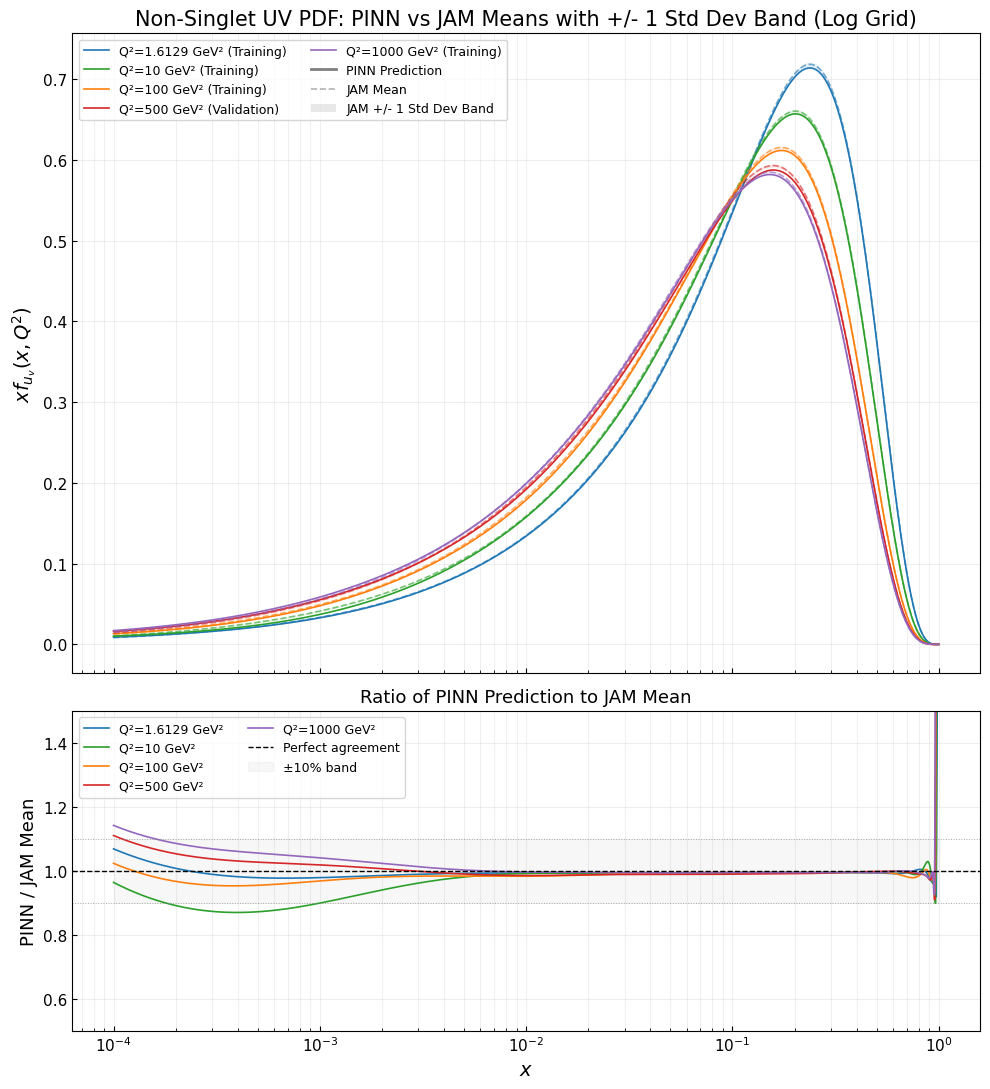

In [25]:
model.eval()
log_x_np = np.log(X)

# Define colors for each Q2 scale
colors = {
    1.6129: '#1f77b4',   # blue
    10:     '#2ca02c',   # green
    100:    '#ff7f0e',   # orange
    500:    '#d62728',   # crimson
    1000:   '#9467bd',   # purple
}

# CHANGE: two-panel figure — top: PDF vs x, bottom: NN/JAM mean ratio
fig, (ax, ax_ratio) = plt.subplots(
    2, 1, figsize=(10, 11),
    gridspec_kw={'height_ratios': [3, 1.5]},
    sharex=True
)

# Store predictions and means per Q² for the ratio panel
preds_by_q2 = {}
means_by_q2 = {}

for q2 in Q2_vals:
    color = colors.get(q2, 'black')
    label_suffix = ' (Validation)' if q2 == VAL_Q2 else ' (Training)'

    # 1. JAM +/- 1 Std Dev band (interpolated in cell 3)
    lo   = treypdf_log[q2]['uv_lo']
    hi   = treypdf_log[q2]['uv_hi']
    mean = treypdf_log[q2]['uv']
    ax.fill_between(X, lo, hi, color=color, alpha=0.12, linewidth=0)
    ax.plot(X, mean, color=color, lw=1.2, ls='--', alpha=0.6)

    # 2. Network prediction
    log_q2_np = np.full(N_x, np.log(q2))
    inp_np    = np.stack([X, log_x_np, log_q2_np], axis=1)
    inp_t     = torch.tensor(inp_np, dtype=torch.float32).to(device)
    with torch.no_grad():
        pred = model(inp_t).cpu().numpy().flatten()
    ax.plot(X, pred, color=color, lw=1.2, label=f'Q²={q2} GeV²{label_suffix}')

    # Store for ratio panel
    preds_by_q2[q2] = pred
    means_by_q2[q2] = mean

# ── Top panel formatting ──────────────────────────────────────────────────────
line_nn   = plt.Line2D([0], [0], color='grey', lw=2,        label='PINN Prediction')
line_med  = plt.Line2D([0], [0], color='grey', lw=1.2,
                        ls='--', alpha=0.6,                  label='JAM Mean')
line_band = plt.matplotlib.patches.Patch(facecolor='grey',
                        alpha=0.18,                          label='JAM +/- 1 Std Dev Band')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + [line_nn, line_med, line_band],
          fontsize=9, loc='upper left', ncol=2)
ax.set_ylabel(r'$xf_{u_v}(x, Q^2)$', size=14)
ax.set_title('Non-Singlet UV PDF: PINN vs JAM Means with +/- 1 Std Dev Band (Log Grid)', size=15)
ax.grid(True, which='both', ls='-', alpha=0.2)
ax.tick_params(direction='in', which='both', labelsize=11)

# ── CHANGE: ratio panel — NN prediction / JAM mean ───────────────────────────
for q2 in Q2_vals:
    color = colors.get(q2, 'black')
    mean  = means_by_q2[q2]
    pred  = preds_by_q2[q2]

    # Mask near-zero JAM mean values to avoid division noise at large x
    safe  = np.abs(mean) > 1e-6
    ratio = np.where(safe, pred / mean, np.nan)
    ax_ratio.plot(X, ratio, color=color, lw=1.2, label=f'Q²={q2} GeV²')

ax_ratio.axhline(1.0,  color='black', lw=1.0, ls='--', label='Perfect agreement')
ax_ratio.axhline(1.1,  color='grey',  lw=0.7, ls=':',  alpha=0.7)
ax_ratio.axhline(0.9,  color='grey',  lw=0.7, ls=':',  alpha=0.7)
ax_ratio.fill_between([X.min(), X.max()], 0.9, 1.1,
                       alpha=0.06, color='grey', label='±10% band')
ax_ratio.set_xscale('log')
ax_ratio.set_xlabel(r'$x$', size=14)
ax_ratio.set_ylabel(r'PINN / JAM Mean', size=13)
ax_ratio.set_title('Ratio of PINN Prediction to JAM Mean', size=13)
ax_ratio.set_ylim(0.5, 1.5)
ax_ratio.legend(fontsize=9, loc='upper left', ncol=2)
ax_ratio.grid(True, which='both', ls='-', alpha=0.2)
ax_ratio.tick_params(direction='in', which='both', labelsize=11)

plt.tight_layout()
plt.show()

# Predict PDFs at Extended $Q^2$



The data file has been updated to include data on a fully log-spaced grid: no interpolation needed.

Various Q^2 levels have been added to assess the model's predictive ability. Ask the model to predict PDFs at a given X as a function of Q^2.

In [22]:
# ── 0. Device ────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ── 1. Load data ──────────────────────────────────────────────────────────────
zip_path = '/work/JAM/rathman/trey24_no_sidis_lo_extended.zip'

# FIX (issue 6): use _ext suffix so these variables do not overwrite the
# training-loop globals treypdf, X, log_x, N_x. If cell 36 were re-run
# after cell 50 with the old names, it would silently use the wrong data.
with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open('trey24_no_sidis_lo.npy') as f:
        treypdf_ext = np.load(f, allow_pickle=True).item()

X_ext     = 10**np.linspace(-4, np.log10(1), 200)
log_x_ext = np.log(X_ext)
N_x_ext   = 200

print('Extended Q² values:')
print(treypdf_ext.keys())

Device: cuda
Extended Q² values:
dict_keys([1.6129, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 3000, 4000])


### Load the Saved Model for Prediction

To use your trained model, you'll first need to ensure the `PINN` class (defined earlier in this notebook) is available in your environment. Then, load the `model_state_dict` from your saved checkpoint. After loading, set the model to evaluation mode (`model.eval()`) for prediction.

Once the model is loaded, you can define an array of `Q2_EXTENDED_VALS` (e.g., from your updated data file or any arbitrary new Q² values) for which you want to generate predictions. For each `Q²` value, you'll create an input tensor similar to how `train_X` and `val_X` were constructed, stacking `x`, `ln(x)`, and `ln(Q²)`. Finally, pass this input to the model to get the PDF predictions.

In [ ]:
# ── 2. Instantiate and Load the Model ────────────────────────────────────
# Ensure the PINN class is defined and run before this cell
model = PINN().to(device)

CHECKPOINT_PATH = '/work/JAM/rathman/v10_pinn_uv_model_with_GLSR.pt'
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only = False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval() # Set model to evaluation mode for inference
print(f'Model loaded from: {CHECKPOINT_PATH}')

# ── 3. Define New Q² Values for Prediction (Example) ───────────────────────
Q2_EXTENDED_VALS = [1.6129, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 3000, 4000]

# ── 4. Generate Predictions for Extended Q² Values ───────────────────────
predictions_extended_q2 = {}

print('\nGenerating predictions for extended Q² values:')
for q2 in Q2_EXTENDED_VALS:
    log_q2_np = np.full(N_x_ext, np.log(q2))  # FIX (issue 6): use N_x_ext
    # Stack X_ext, ln(X_ext), and ln(Q^2) as input features
    inp_np = np.stack([X_ext, log_x_ext, log_q2_np], axis=1)  # FIX (issue 6)
    inp_t  = torch.tensor(inp_np, dtype=torch.float32).to(device)

    with torch.no_grad():
        pred = model(inp_t).cpu().numpy().flatten()

    predictions_extended_q2[q2] = pred
    print(f'  Generated prediction for Q² = {q2} GeV²')


Now plot predictions at a given X as a function of Q^2.

Selected x for Q² evolution (subplot 1): 0.0010 (closest to 0.001)
Selected x for Q² evolution (subplot 2): 0.0196 (closest to 0.02)
Selected x for Q² evolution (subplot 3): 0.0988 (closest to 0.1)
Selected x for Q² evolution (subplot 4): 0.6906 (closest to 0.7)


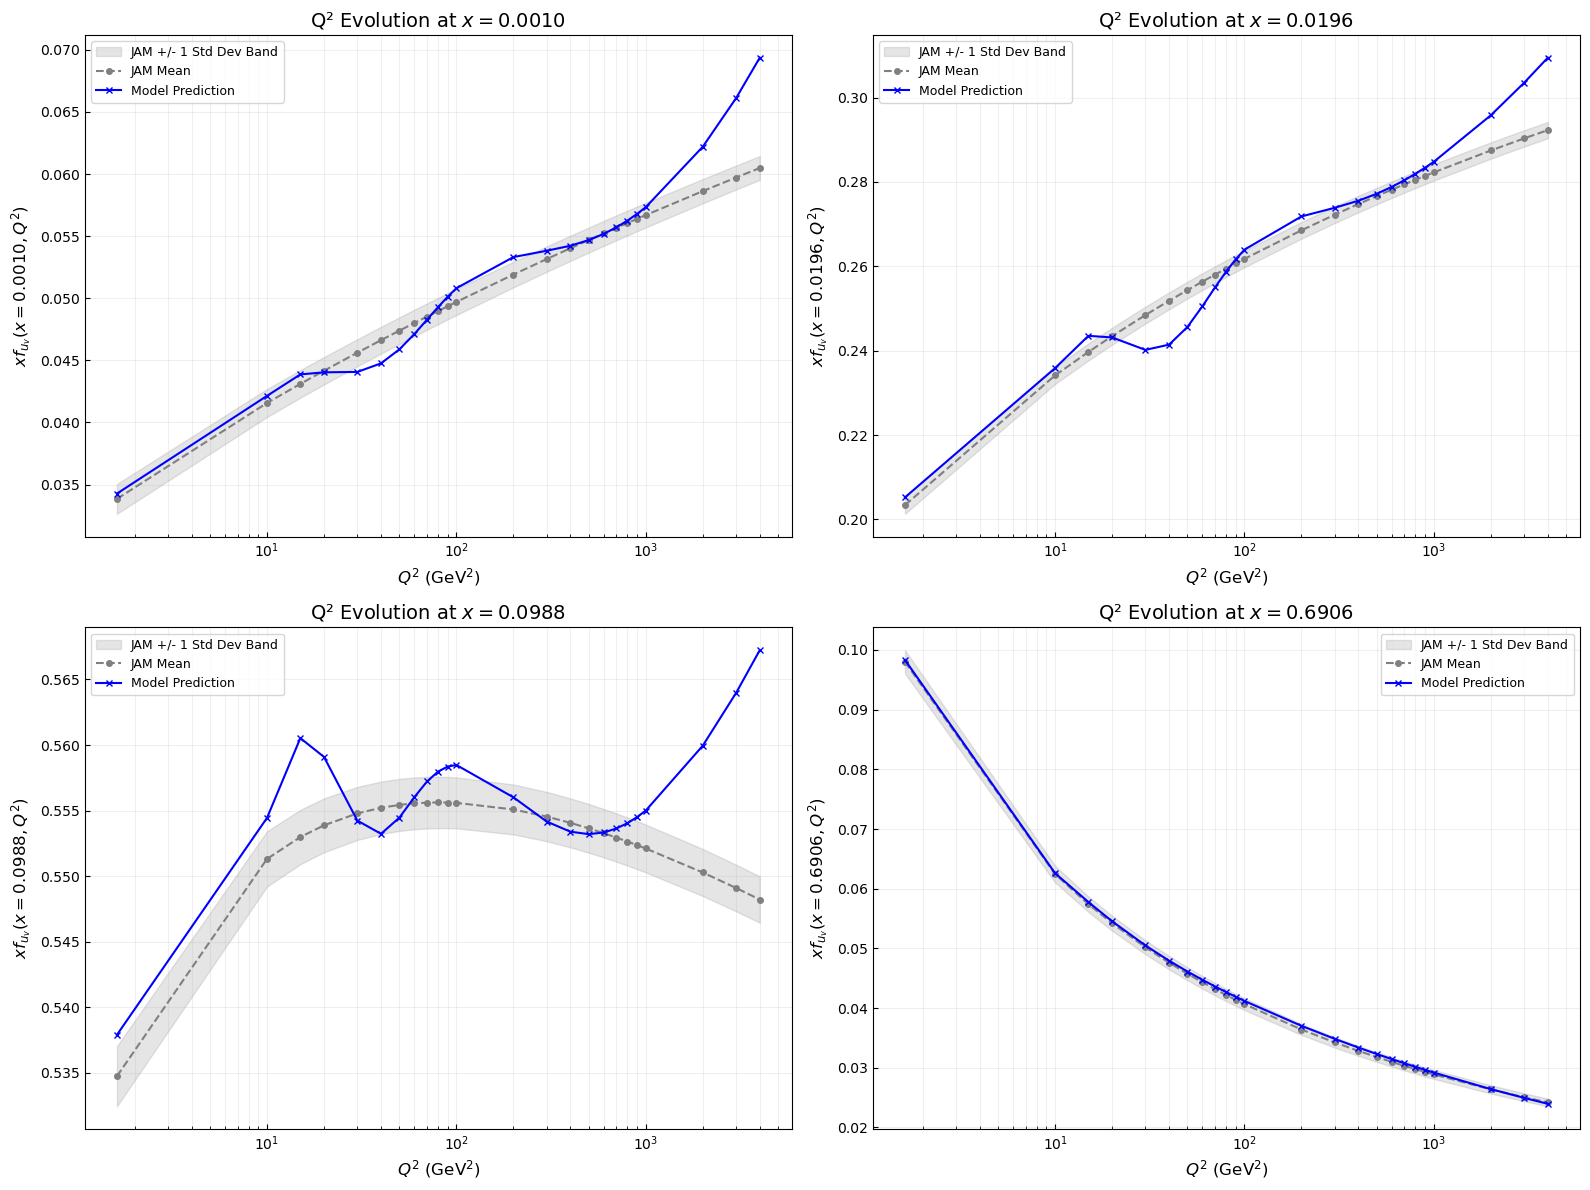

In [25]:

# Choose the fixed x values to plot
FIXED_X_VALS = [1e-3, 0.02, 0.1, 0.7]

# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12)) # 2 rows, 2 columns
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

for i, fixed_x in enumerate(FIXED_X_VALS):
    ax = axes[i] # Get the current subplot axis

    # Find the index of the closest x value in the X array
    x_idx = (np.abs(X_ext - fixed_x)).argmin()  # FIX (issue 6): use X_ext
    actual_x_val = X_ext[x_idx]  # FIX (issue 6): use X_ext
    print(f"Selected x for Q² evolution (subplot {i+1}): {actual_x_val:.4f} (closest to {fixed_x})")

    # Prepare lists to store data for the DataFrame for the current x-value
    q2_values_plot = []
    model_predictions_at_x = []
    jam_mean_at_x = []
    jam_lo_at_x = []
    jam_hi_at_x = []

    for q2 in sorted(Q2_EXTENDED_VALS):
        q2_values_plot.append(q2)

        # Get model prediction at the fixed x_idx
        model_predictions_at_x.append(predictions_extended_q2[q2][x_idx])

        # Get JAM data if available for this Q²
        if q2 in treypdf_ext:  # FIX (issue 6): use treypdf_ext
            uv_reps = treypdf_ext[q2]['uv']
            uv_mean = np.mean(uv_reps, axis=0)
            uv_std  = np.std(uv_reps, axis=0)
            uv_lo   = uv_mean - uv_std
            uv_hi   = uv_mean + uv_std

            jam_mean_at_x.append(uv_mean[x_idx])
            jam_lo_at_x.append(uv_lo[x_idx])
            jam_hi_at_x.append(uv_hi[x_idx])
        else:
            jam_mean_at_x.append(np.nan) # Use NaN if no JAM data for this Q²
            jam_lo_at_x.append(np.nan)
            jam_hi_at_x.append(np.nan)

    # Create a DataFrame for the current x-value
    df_q2_evolution_current_x = pd.DataFrame({
        'Q2': q2_values_plot,
        'Model_Prediction': model_predictions_at_x,
        'JAM_Mean': jam_mean_at_x,
        'JAM_Lo': jam_lo_at_x,
        'JAM_Hi': jam_hi_at_x
    })

    # Plot JAM bands and means (where available) for the current x-value
    ajam_data_present = df_q2_evolution_current_x.dropna(subset=['JAM_Mean'])
    ax.fill_between(
        ajam_data_present['Q2'],
        ajam_data_present['JAM_Lo'],
        ajam_data_present['JAM_Hi'],
        color='grey', alpha=0.2, label='JAM +/- 1 Std Dev Band'
    )
    ax.plot(
        ajam_data_present['Q2'],
        ajam_data_present['JAM_Mean'],
        color='grey', linestyle='--', marker='o', markersize=4, label='JAM Mean'
    )

    # Plot Model Predictions for the current x-value
    ax.plot(
        df_q2_evolution_current_x['Q2'],
        df_q2_evolution_current_x['Model_Prediction'],
        color='blue', linestyle='-', marker='x', markersize=4, label='Model Prediction'
    )

    ax.set_xscale('log')
    ax.set_xlabel(r'$Q^2$ (GeV$^2$)', size=12)
    ax.set_ylabel(r'$xf_{{u_v}}(x={:.4f}, Q^2)$'.format(actual_x_val), size=12)
    ax.set_title(f'Q² Evolution at $x={actual_x_val:.4f}$', size=14)
    ax.grid(True, which="both", ls="-", alpha=0.2)
    ax.tick_params(direction='in', which='both', labelsize=10)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()